# Robust Federated Learning for Intensive Care Unit Mortality Prediction Across a Heterogeneous Hospital Network

**Full reproducible pipeline: cohort filtering &rarr; feature extraction &rarr; architecture selection &rarr; class imbalance handling &rarr; federated learning (FedAvg/FedProx) &rarr; robustness stress-testing &rarr; hospital-size stratification &rarr; APACHE benchmark &rarr; explainability.**

Dataset: eICU Collaborative Research Database v2.0 (`patient.csv`, `lab.csv`, `vitalPeriodic.csv`, `apachePatientResult.csv`).

This notebook uses a **single, unified training budget (60 communication rounds, 5 independent seeds) across every federated experiment**, so that natural-condition and stress-condition results are always directly comparable without any confound from differing compute budgets.


## 0. Setup, Configuration, and Imports

In [1]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
import time
import re
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)
from scipy.stats import wilcoxon, mannwhitneyu, norm

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

# ---------------------------------------------------------------------------
# PATHS -- update BASE_DIR to your local working directory
# ---------------------------------------------------------------------------
BASE_DIR = Path("./pipeline_run")
DATA_DIR = BASE_DIR / "eicu_data"          # patient.csv, lab.csv, vitalPeriodic.csv, apachePatientResult.csv
COHORT_DIR = BASE_DIR / "cohort_output"
FEATURE_DIR = BASE_DIR / "feature_output"
SPLIT_DIR = BASE_DIR / "split_output"
FIGURE_DIR = BASE_DIR / "figures"
RESULTS_DIR = BASE_DIR / "results"
for d in [COHORT_DIR, FEATURE_DIR, SPLIT_DIR, FIGURE_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# GLOBAL EXPERIMENT CONFIG
# ---------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

SEEDS = [42, 43, 44, 45, 46]          # full 5-seed budget
NUM_ROUNDS = 60                        # UNIFIED across Phase C and Phase D -- eliminates any
                                        # round-count confound between natural and stress conditions
LOCAL_EPOCHS = 3
FL_PATIENCE_ROUNDS = 10
BATCH_SIZE = 256
LR_RATE = 0.001
FEDPROX_MU = 0.01
FOCAL_ALPHA, FOCAL_GAMMA = 0.75, 2.0

OBS_WINDOW_MIN = 24 * 60
MIN_STAY_MIN = 24 * 60
VITAL_BIN_MIN = 60
LAB_BIN_MIN = 8 * 60
HOSPITAL_TIER = (300, 15)              # (min_stays, min_positive_cases) -- relaxed tier
TOP_K_DX = 20

VITAL_COLS = ["heartrate", "respiration", "sao2", "systemicsystolic",
              "systemicdiastolic", "systemicmean", "temperature"]
HIGH_FREQ_VITALS = ["heartrate", "respiration", "sao2"]
LAB_PANEL = ["glucose", "creatinine", "BUN", "sodium", "potassium", "bicarbonate",
             "Hgb", "Hct", "platelets x 1000", "WBC x 1000", "lactate", "albumin",
             "total bilirubin", "PTT", "chloride", "-bands"]
CHUNK_SIZE = 2_000_000

LABEL_NOISE_SEVERITIES = [0.10, 0.20, 0.30]
INPUT_NOISE_SEVERITIES = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]   # extended beyond 0.10 SD, which
                                                                  # produced negligible degradation
                                                                  # and was too mild a test on its own
BYZANTINE_SEVERITIES = [0.05, 0.10, 0.20]
BYZANTINE_ATTACK_TYPES = ["random_norm_matched", "sign_flip", "scaled_replacement"]  # the original
                                                                  # random-norm-matched attack alone is
                                                                  # a constrained model, not general
                                                                  # Byzantine behavior -- two additional,
                                                                  # precisely-named attacks are added
BYZANTINE_BOOST_FACTOR = 10.0    # amplification factor for the scaled_replacement attack
NUMERIC_PREFIXES = ("vit_", "lab_", "age")

print("Configuration loaded.")


Using device: cpu
Configuration loaded.


## 1. Cohort Filtering

Inclusion criteria: age &ge; 18, first ICU stay only, stay duration &ge; 24h. Hospitals are kept as FL clients only if they clear a minimum-volume threshold (300 stays, 15 positive mortality cases) -- chosen to preserve as many real hospitals as possible while keeping per-client statistics meaningful.

### 1a. Leakage Check and Early-Death Disclosure

Two diagnostics on the pre-filter patient table: (1) whether any retained patient
(by `uniquepid`) has ICU stays at more than one hospital, which would violate the
FL client-independence assumption; (2) how many patients died within the first 24h
observation window and were therefore excluded by the stay-length criterion.

In [2]:

def load_patient_table():    
    cols = ["patientunitstayid", "patienthealthsystemstayid", "hospitalid", "uniquepid",
        "age", "gender", "unitdischargeoffset", "unitdischargestatus",
        "hospitaldischargestatus", "apacheadmissiondx", "unittype"]
    return pd.read_csv(DATA_DIR / "patient.csv", usecols=lambda c: c in cols)


def apply_inclusion_criteria(patient_df):
    df = patient_df.copy()
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df = df[(df["age"] >= 18) | df["age"].isna()]

    if "patienthealthsystemstayid" in df.columns:
        df = df.sort_values("patientunitstayid").drop_duplicates(
            subset="patienthealthsystemstayid", keep="first"
        )

    df = df[df["unitdischargeoffset"] >= MIN_STAY_MIN]
    df["mortality_label"] = (df["hospitaldischargestatus"].str.upper() == "EXPIRED").astype(int)
    df = df.dropna(subset=["hospitaldischargestatus"])

    # One qualifying stay per PATIENT (uniquepid), globally.
    # Guarantees every patient belongs to exactly one hospital / one FL client.
    df = df.sort_values("patientunitstayid").drop_duplicates(subset="uniquepid", keep="first")

    return df


def summarize_by_hospital(cohort_df):
    summary = cohort_df.groupby("hospitalid").agg(
        n_stays=("patientunitstayid", "count"),
        n_positive=("mortality_label", "sum"),
    ).reset_index()
    summary["prevalence"] = summary["n_positive"] / summary["n_stays"]
    return summary.sort_values("n_stays", ascending=False)


print("Loading patient table...")
patient_df = load_patient_table()

print("Applying inclusion criteria...")
cohort_df = apply_inclusion_criteria(patient_df)
print(f"Patients after inclusion criteria: {len(cohort_df)}")
cohort_df.to_csv(COHORT_DIR / "filtered_cohort_full.csv", index=False)

hospital_summary = summarize_by_hospital(cohort_df)
hospital_summary.to_csv(COHORT_DIR / "hospital_summary_all.csv", index=False)

min_stays, min_positive = HOSPITAL_TIER
qualifying_hospitals = hospital_summary[
    (hospital_summary["n_stays"] >= min_stays) & (hospital_summary["n_positive"] >= min_positive)
]
qualifying_hospitals.to_csv(COHORT_DIR / "qualifying_hospitals.csv", index=False)

print(f"\nQualifying hospitals: {len(qualifying_hospitals)}")
print(f"Total patients in qualifying hospitals: {qualifying_hospitals['n_stays'].sum()}")
print(f"Total positive cases: {qualifying_hospitals['n_positive'].sum()}")


Loading patient table...
Applying inclusion criteria...
Patients after inclusion criteria: 97963

Qualifying hospitals: 94
Total patients in qualifying hospitals: 83909
Total positive cases: 7957


In [3]:
# --- Cohort-flow tracking table ---
_df = patient_df.copy()
_df["age"] = pd.to_numeric(_df["age"], errors="coerce")
steps = [("raw patient table", _df)]

_df = _df[(_df["age"] >= 18) | _df["age"].isna()]
steps.append(("age >= 18", _df))

_df = _df.sort_values("patientunitstayid").drop_duplicates(subset="patienthealthsystemstayid", keep="first")
steps.append(("first stay per patienthealthsystemstayid", _df))

_df = _df[_df["unitdischargeoffset"] >= MIN_STAY_MIN]
steps.append((">=24h stay length", _df))

_df["mortality_label"] = (_df["hospitaldischargestatus"].str.upper() == "EXPIRED").astype(int)
_df = _df.dropna(subset=["hospitaldischargestatus"])
steps.append(("non-missing outcome", _df))

_df = _df.sort_values("patientunitstayid").drop_duplicates(subset="uniquepid", keep="first")
steps.append(("one stay per uniquepid (patient-level)", _df))

flow_df = pd.DataFrame([
    {"step": name, "n_records": len(d), "n_unique_patients": d["uniquepid"].nunique()}
    for name, d in steps
])
print(flow_df.to_string(index=False))
flow_df.to_csv(COHORT_DIR / "cohort_flow_table.csv", index=False)

<notebook cell>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["mortality_label"] = (_df["hospitaldischargestatus"].str.upper() == "EXPIRED").astype(int)


                                    step  n_records  n_unique_patients
                       raw patient table     200859             139367
                               age >= 18     200329             138942
first stay per patienthealthsystemstayid     165879             138942
                       >=24h stay length     114099              98781
                     non-missing outcome     113056              97963
  one stay per uniquepid (patient-level)      97963              97963


In [4]:
# --- Cross-hospital patient leakage check ---
pid_hosp = patient_df.groupby("uniquepid")["hospitalid"].nunique()
multi_hospital_patients = (pid_hosp > 1).sum()
pct_multi = multi_hospital_patients / len(pid_hosp) * 100
print(f"Patients (uniquepid) with stays at >1 hospital: {multi_hospital_patients}/{len(pid_hosp)} ({pct_multi:.2f}%)")

# Restrict to patients actually retained in the final cohort
retained_pids = patient_df.loc[
    patient_df["patientunitstayid"].isin(cohort_df["patientunitstayid"]), "uniquepid"
]
retained_multi = pid_hosp.loc[pid_hosp.index.isin(retained_pids)]
retained_multi_hosp = (retained_multi > 1).sum()
print(f"Of retained cohort patients, {retained_multi_hosp}/{len(retained_multi)} "
      f"({retained_multi_hosp/len(retained_multi)*100:.2f}%) have another stay at a different hospital "
      f"(that other stay was excluded, so no patient contributes to >1 FL client).")

# --- Deaths before 24h (excluded by the >=24h stay-length criterion) ---
pre_stay_filter = patient_df.copy()
pre_stay_filter["age"] = pd.to_numeric(pre_stay_filter["age"], errors="coerce")
pre_stay_filter = pre_stay_filter[(pre_stay_filter["age"] >= 18) | pre_stay_filter["age"].isna()]
early_deaths = pre_stay_filter[
    (pre_stay_filter["unitdischargeoffset"] < MIN_STAY_MIN) &
    (pre_stay_filter["hospitaldischargestatus"].str.upper() == "EXPIRED")
]
print(f"\nAdult patients who died before the 24h observation window closed "
      f"(excluded by the stay-length criterion): {len(early_deaths)}")

Patients (uniquepid) with stays at >1 hospital: 4070/139367 (2.92%)
Of retained cohort patients, 3669/97963 (3.75%) have another stay at a different hospital (that other stay was excluded, so no patient contributes to >1 FL client).

Adult patients who died before the 24h observation window closed (excluded by the stay-length criterion): 5981


In [5]:
# --- Within-hospital duplicate patient check ---
# Does the same uniquepid contribute more than one qualifying stay
# at the SAME hospital? (apply_inclusion_criteria only dedupes by
# patienthealthsystemstayid, not by uniquepid.)
cohort_pids = patient_df.loc[
    patient_df["patientunitstayid"].isin(cohort_df["patientunitstayid"]),
    ["patientunitstayid", "hospitalid", "uniquepid"]
]
dupe_counts = cohort_pids.groupby(["hospitalid", "uniquepid"]).size()
n_dupe_patients = (dupe_counts > 1).sum()
print(f"uniquepid values with >1 qualifying stay at the SAME hospital: "
      f"{n_dupe_patients} (out of {cohort_pids['uniquepid'].nunique()} unique patients in the retained cohort)")
if n_dupe_patients > 0:
    print("These patients contribute multiple rows within one hospital's cohort and MUST be "
          "grouped together when the train/val/test split is performed, to avoid split leakage.")

uniquepid values with >1 qualifying stay at the SAME hospital: 0 (out of 97963 unique patients in the retained cohort)


In [6]:
cohort_pids = patient_df.loc[
    patient_df["patientunitstayid"].isin(cohort_df["patientunitstayid"]),
    ["patientunitstayid", "hospitalid", "uniquepid"]
]
dupe_counts = cohort_pids.groupby(["hospitalid", "uniquepid"]).size()
n_dupe_patients = (dupe_counts > 1).sum()
print(f"uniquepid values with >1 qualifying stay at the SAME hospital: {n_dupe_patients}")

multi_hosp_in_cohort = cohort_pids.groupby("uniquepid")["hospitalid"].nunique()
n_multi_hosp = (multi_hosp_in_cohort > 1).sum()
print(f"uniquepid values retained at >1 hospital: {n_multi_hosp}")

uniquepid values with >1 qualifying stay at the SAME hospital: 0
uniquepid values retained at >1 hospital: 0


In [7]:
# --- Mortality prevalence before vs. after the >=24h stay-length filter ---
# The 24h stay-length criterion mechanically excludes a substantial number of
# early deaths, so prevalence is reported on both sides of that filter to
# characterize this effect.
before_24h = patient_df.copy()
before_24h["age"] = pd.to_numeric(before_24h["age"], errors="coerce")
before_24h = before_24h[(before_24h["age"] >= 18) | before_24h["age"].isna()]
before_24h = before_24h.sort_values("patientunitstayid").drop_duplicates(
    subset="patienthealthsystemstayid", keep="first"
)
before_24h["mortality_label"] = (before_24h["hospitaldischargestatus"].str.upper() == "EXPIRED").astype(int)
before_24h = before_24h.dropna(subset=["hospitaldischargestatus"])

prev_before = before_24h["mortality_label"].mean()
prev_after = cohort_df["mortality_label"].mean()
print(f"Mortality prevalence BEFORE >=24h stay-length filter: {prev_before:.4f} (n={len(before_24h)})")
print(f"Mortality prevalence AFTER  >=24h stay-length filter: {prev_after:.4f} (n={len(cohort_df)})")


Mortality prevalence BEFORE >=24h stay-length filter: 0.0889 (n=164406)
Mortality prevalence AFTER  >=24h stay-length filter: 0.0929 (n=97963)


## 2. Dataset Statistics and Exploratory Figures

Descriptive statistics of the final cohort, for the paper's dataset section.

=== Cohort summary ===
Hospitals: 94
Patients: 83909
Overall mortality prevalence: 0.0948
Median age: 65.0
Gender distribution:
gender
Male       0.547296
Female     0.452537
Unknown    0.000119
Other      0.000048
Name: proportion, dtype: float64


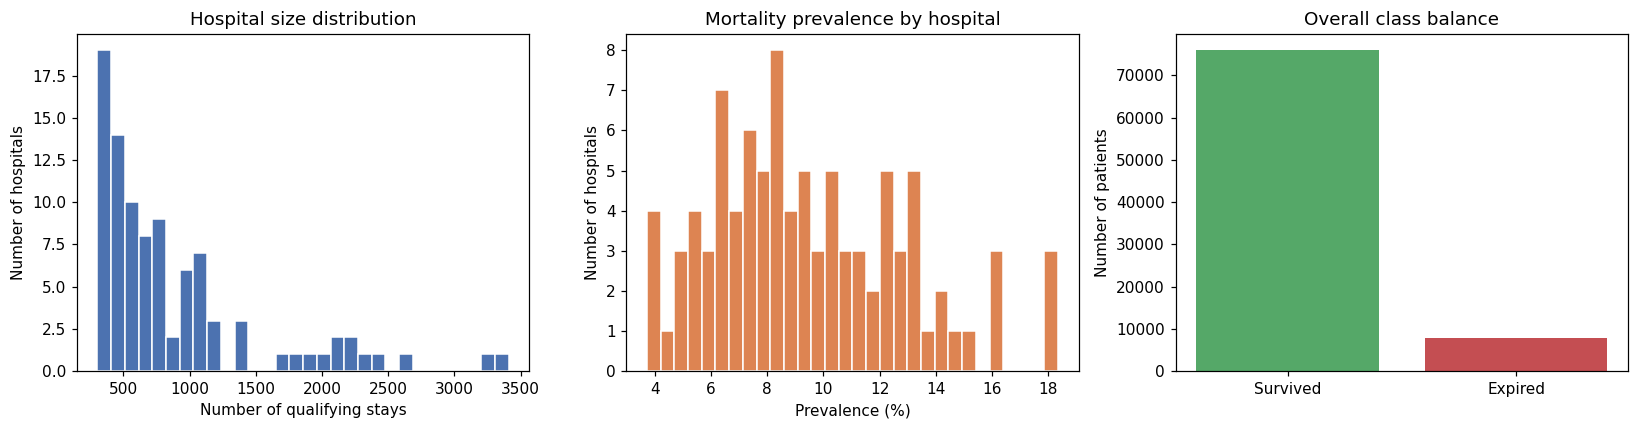

In [8]:

qualifying_ids = set(qualifying_hospitals["hospitalid"])
final_cohort = cohort_df[cohort_df["hospitalid"].isin(qualifying_ids)]

print("=== Cohort summary ===")
print(f"Hospitals: {final_cohort['hospitalid'].nunique()}")
print(f"Patients: {len(final_cohort)}")
print(f"Overall mortality prevalence: {final_cohort['mortality_label'].mean():.4f}")
print(f"Median age: {final_cohort['age'].median():.1f}")
print(f"Gender distribution:\n{final_cohort['gender'].value_counts(normalize=True)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(qualifying_hospitals["n_stays"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Hospital size distribution")
axes[0].set_xlabel("Number of qualifying stays")
axes[0].set_ylabel("Number of hospitals")

axes[1].hist(qualifying_hospitals["prevalence"] * 100, bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Mortality prevalence by hospital")
axes[1].set_xlabel("Prevalence (%)")
axes[1].set_ylabel("Number of hospitals")

axes[2].bar(["Survived", "Expired"], final_cohort["mortality_label"].value_counts().sort_index(),
            color=["#55A868", "#C44E52"])
axes[2].set_title("Overall class balance")
axes[2].set_ylabel("Number of patients")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "dataset_statistics.png", bbox_inches="tight")
plt.show()


## 3. Feature Extraction (Vitals + Labs)

Vitals resampled to 24 hourly bins (mean; additionally min/max for heart rate, respiration, SpO2). Labs resampled to 3 eight-hour bins over a fixed panel. Missing values forward/backward-filled, remaining gaps set to a -1 sentinel.

In [9]:

def load_qualifying_stay_ids():
    cohort = pd.read_csv(COHORT_DIR / "filtered_cohort_full.csv")
    cohort = cohort[cohort["hospitalid"].isin(qualifying_ids)]
    stay_ids = set(cohort["patientunitstayid"])
    return stay_ids, cohort


def extract_vitals(stay_ids):
    bins_accum = []
    usecols = ["patientunitstayid", "observationoffset"] + VITAL_COLS
    reader = pd.read_csv(DATA_DIR / "vitalPeriodic.csv", usecols=lambda c: c in usecols, chunksize=CHUNK_SIZE)
    for chunk in reader:
        chunk = chunk[chunk["patientunitstayid"].isin(stay_ids)]
        chunk = chunk[(chunk["observationoffset"] >= 0) & (chunk["observationoffset"] < OBS_WINDOW_MIN)]
        if chunk.empty:
            continue
        chunk["hour_bin"] = (chunk["observationoffset"] // VITAL_BIN_MIN).astype(int)
        bins_accum.append(chunk)

    vitals = pd.concat(bins_accum, ignore_index=True)
    agg_dict = {col: "mean" for col in VITAL_COLS}
    grouped_mean = vitals.groupby(["patientunitstayid", "hour_bin"]).agg(agg_dict).reset_index()
    grouped_minmax = vitals.groupby(["patientunitstayid", "hour_bin"])[HIGH_FREQ_VITALS].agg(["min", "max"])
    grouped_minmax.columns = [f"{c}_{s}" for c, s in grouped_minmax.columns]
    grouped_minmax = grouped_minmax.reset_index()
    return grouped_mean.merge(grouped_minmax, on=["patientunitstayid", "hour_bin"], how="left")


def extract_labs(stay_ids):
    bins_accum = []
    usecols = ["patientunitstayid", "labresultoffset", "labname", "labresult"]
    reader = pd.read_csv(DATA_DIR / "lab.csv", usecols=lambda c: c in usecols, chunksize=CHUNK_SIZE)
    for chunk in reader:
        chunk = chunk[chunk["patientunitstayid"].isin(stay_ids)]
        chunk = chunk[chunk["labname"].isin(LAB_PANEL)]
        chunk = chunk[(chunk["labresultoffset"] >= 0) & (chunk["labresultoffset"] < OBS_WINDOW_MIN)]
        if chunk.empty:
            continue
        chunk["lab_bin"] = (chunk["labresultoffset"] // LAB_BIN_MIN).astype(int)
        bins_accum.append(chunk)

    labs = pd.concat(bins_accum, ignore_index=True)
    labs_binned = labs.groupby(["patientunitstayid", "lab_bin", "labname"])["labresult"].mean().reset_index()
    return labs_binned.pivot_table(index=["patientunitstayid", "lab_bin"], columns="labname", values="labresult").reset_index()


def fill_and_flatten(vitals_binned, labs_wide, stay_ids):
    vital_cols = [c for c in vitals_binned.columns if c not in ("patientunitstayid", "hour_bin")]
    all_hours = pd.MultiIndex.from_product(
        [list(stay_ids), range(OBS_WINDOW_MIN // VITAL_BIN_MIN)], names=["patientunitstayid", "hour_bin"]
    ).to_frame(index=False)
    vitals_full = all_hours.merge(vitals_binned, on=["patientunitstayid", "hour_bin"], how="left")
    vitals_full[vital_cols] = vitals_full.groupby("patientunitstayid")[vital_cols].ffill().bfill()
    vitals_full[vital_cols] = vitals_full[vital_cols].fillna(-1)
    vitals_flat = vitals_full.pivot_table(index="patientunitstayid", columns="hour_bin", values=vital_cols)
    vitals_flat.columns = [f"vit_{c}_h{b}" for c, b in vitals_flat.columns]
    vitals_flat = vitals_flat.reset_index()

    lab_cols = [c for c in labs_wide.columns if c not in ("patientunitstayid", "lab_bin")]
    all_lab_bins = pd.MultiIndex.from_product(
        [list(stay_ids), range(OBS_WINDOW_MIN // LAB_BIN_MIN)], names=["patientunitstayid", "lab_bin"]
    ).to_frame(index=False)
    labs_full = all_lab_bins.merge(labs_wide, on=["patientunitstayid", "lab_bin"], how="left")
    labs_full[lab_cols] = labs_full.groupby("patientunitstayid")[lab_cols].ffill().bfill()
    labs_full[lab_cols] = labs_full[lab_cols].fillna(-1)
    labs_flat = labs_full.pivot_table(index="patientunitstayid", columns="lab_bin", values=lab_cols)
    labs_flat.columns = [f"lab_{c}_b{b}" for c, b in labs_flat.columns]
    labs_flat = labs_flat.reset_index()

    return vitals_flat.merge(labs_flat, on="patientunitstayid", how="outer")


def attach_static_and_label(feature_df, cohort):
    static_cols = ["patientunitstayid", "hospitalid", "age", "gender", "unittype", "apacheadmissiondx", "mortality_label"]
    static_cols = [c for c in static_cols if c in cohort.columns]
    final = cohort[static_cols].merge(feature_df, on="patientunitstayid", how="left")
    feat_cols = [c for c in final.columns if c.startswith(("vit_", "lab_"))]
    final[feat_cols] = final[feat_cols].fillna(-1)
    return final


stay_ids, cohort_for_features = load_qualifying_stay_ids()
print(f"Extracting features for {len(stay_ids)} patients...")
vitals_binned = extract_vitals(stay_ids)
labs_wide = extract_labs(stay_ids)
feature_df = fill_and_flatten(vitals_binned, labs_wide, stay_ids)
final_features = attach_static_and_label(feature_df, cohort_for_features)

out_path = FEATURE_DIR / "features_flat.parquet"
final_features.to_parquet(out_path, index=False)
print(f"Saved {len(final_features)} patients x {final_features.shape[1]} columns to {out_path}")


Extracting features for 83909 patients...
Saved 83909 patients x 367 columns to ./pipeline_run/feature_output/features_flat.parquet


## 4. Train/Val/Test Split, Categorical Encoding, Normalization

Stratified 70/10/20 split **per hospital** (not chronological -- eICU de-identifies timestamps independently per patient, so no shared clock exists to sort by). Age's `>89` convention imputed to 90. Diagnosis bucketed to top-20 + "Other". Z-score normalization fit on training data only, with sentinel-preserving handling of missing (-1) values.

In [10]:

from sklearn.model_selection import train_test_split

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.10, 0.20
SENTINEL_MISSING = -1
POST_NORM_SENTINEL = -5.0
RANDOM_SEED = 42


def impute_age(df):
    df = df.copy()
    df["age"] = df["age"].fillna(90)
    return df


def encode_gender(df):
    df = df.copy()
    mode = df["gender"].mode(dropna=True)[0]
    df["gender"] = df["gender"].fillna(mode)
    df["gender_male"] = (df["gender"] == "Male").astype(int)
    return df.drop(columns=["gender"])


def encode_unittype(df):
    df = df.copy()
    df["unittype"] = df["unittype"].fillna("Unknown")
    dummies = pd.get_dummies(df["unittype"], prefix="unittype")
    return pd.concat([df.drop(columns=["unittype"]), dummies], axis=1)


def encode_admission_dx(df, top_k=TOP_K_DX):
    df = df.copy()
    df["apacheadmissiondx"] = df["apacheadmissiondx"].fillna("Unknown")
    top_cats = df["apacheadmissiondx"].value_counts().nlargest(top_k).index
    df["dx_bucketed"] = df["apacheadmissiondx"].where(df["apacheadmissiondx"].isin(top_cats), "Other")
    dummies = pd.get_dummies(df["dx_bucketed"], prefix="dx")
    return pd.concat([df.drop(columns=["apacheadmissiondx", "dx_bucketed"]), dummies], axis=1)


def stratified_split_per_hospital(df, patient_df=patient_df):
    df = df.copy()
    stayid_to_pid = patient_df.set_index("patientunitstayid")["uniquepid"]
    df["uniquepid"] = df["patientunitstayid"].map(stayid_to_pid)

    train_ids, val_ids, test_ids = [], [], []
    for hosp_id, group in df.groupby("hospitalid"):
        # one row per patient: patient-level label is 1 if ANY of that
        # patient's qualifying stays at this hospital was fatal, else 0
        patient_level = group.groupby("uniquepid")["mortality_label"].max().reset_index()
        pids_h = patient_level["uniquepid"].values
        labels_h = patient_level["mortality_label"].values

        train_pid, temp_pid = train_test_split(pids_h, test_size=(VAL_FRAC + TEST_FRAC),
                                                stratify=labels_h, random_state=RANDOM_SEED)
        temp_labels = patient_level.set_index("uniquepid").loc[temp_pid, "mortality_label"].values
        val_pid, test_pid = train_test_split(temp_pid, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
                                              stratify=temp_labels, random_state=RANDOM_SEED)

        train_pid, val_pid, test_pid = set(train_pid), set(val_pid), set(test_pid)
        train_ids.extend(group.loc[group["uniquepid"].isin(train_pid), "patientunitstayid"].tolist())
        val_ids.extend(group.loc[group["uniquepid"].isin(val_pid), "patientunitstayid"].tolist())
        test_ids.extend(group.loc[group["uniquepid"].isin(test_pid), "patientunitstayid"].tolist())

    return train_ids, val_ids, test_ids


def get_feature_columns(df, exclude):
    return [c for c in df.columns if c not in exclude]


def normalize_with_sentinel_preservation(df, feature_cols, train_mask):
    df = df.copy()
    stats = {}
    numeric_cols = [c for c in feature_cols if c.startswith(("vit_", "lab_", "age"))]
    for col in numeric_cols:
        train_vals = df.loc[train_mask, col]
        non_sentinel = train_vals[train_vals != SENTINEL_MISSING]
        mean = non_sentinel.mean() if len(non_sentinel) else 0.0
        std = non_sentinel.std() if len(non_sentinel) else 1.0
        std = std if std > 1e-8 else 1.0
        stats[col] = (mean, std)
        was_sentinel = df[col] == SENTINEL_MISSING
        df[col] = (df[col] - mean) / std
        df.loc[was_sentinel, col] = POST_NORM_SENTINEL
    return df, stats


df = pd.read_parquet(FEATURE_DIR / "features_flat.parquet")
df = impute_age(df)
df = encode_gender(df)
df = encode_unittype(df)
df = encode_admission_dx(df)

train_ids, val_ids, test_ids = stratified_split_per_hospital(df)
df["split"] = np.select(
    [df["patientunitstayid"].isin(train_ids), df["patientunitstayid"].isin(val_ids), df["patientunitstayid"].isin(test_ids)],
    ["train", "val", "test"], default="unassigned",
)
assert (df["split"] == "unassigned").sum() == 0

EXCLUDE_COLS = {"patientunitstayid", "hospitalid", "mortality_label", "split"}
feature_cols = get_feature_columns(df, EXCLUDE_COLS)
train_mask = df["split"] == "train"
df_norm, norm_stats = normalize_with_sentinel_preservation(df, feature_cols, train_mask)

for split_name in ["train", "val", "test"]:
    split_df = df_norm[df_norm["split"] == split_name].drop(columns=["split"])
    split_df.to_parquet(SPLIT_DIR / f"{split_name}.parquet", index=False)
    print(f"{split_name}: {len(split_df)} patients, prevalence={split_df['mortality_label'].mean():.4f}")

print(f"\nFeature dimensionality: {len(feature_cols)}")


train: 58684 patients, prevalence=0.0948
val: 8381 patients, prevalence=0.0955
test: 16844 patients, prevalence=0.0946

Feature dimensionality: 391


In [11]:
# --- Split-leakage check: does any uniquepid appear in more than one split? ---
train_df_chk = pd.read_parquet(SPLIT_DIR / "train.parquet")
val_df_chk = pd.read_parquet(SPLIT_DIR / "val.parquet")
test_df_chk = pd.read_parquet(SPLIT_DIR / "test.parquet")

stayid_to_pid = patient_df.set_index("patientunitstayid")["uniquepid"]
for name, d in [("train", train_df_chk), ("val", val_df_chk), ("test", test_df_chk)]:
    d["uniquepid"] = d["patientunitstayid"].map(stayid_to_pid) if "patientunitstayid" in d.columns else None

all_splits = pd.concat([
    train_df_chk[["uniquepid"]].assign(split="train"),
    val_df_chk[["uniquepid"]].assign(split="val"),
    test_df_chk[["uniquepid"]].assign(split="test"),
])
overlap = all_splits.groupby("uniquepid")["split"].nunique()
n_overlap = (overlap > 1).sum()
print(f"uniquepid values appearing in more than one split (train/val/test): {n_overlap}")

uniquepid values appearing in more than one split (train/val/test): 0


## 5. Shared Utilities: Models, Training, and Evaluation Functions

Defined once here and reused across every subsequent phase.

In [12]:

def _coerce_to_float32_array(df_slice):
    X_df = df_slice.copy()
    non_numeric = X_df.select_dtypes(exclude=[np.number, bool]).columns.tolist()
    if non_numeric:
        for col in non_numeric:
            X_df[col] = pd.to_numeric(X_df[col], errors="coerce")
        X_df[non_numeric] = X_df[non_numeric].fillna(0)
    return X_df.astype(np.float32).values


def to_tensors(df, feat_cols):
    X = torch.tensor(_coerce_to_float32_array(df[feat_cols]), dtype=torch.float32)
    y = torch.tensor(df["mortality_label"].values, dtype=torch.float32)
    return X, y


# --------------------------- Models ---------------------------

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(-1)


class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2), nn.ReLU(),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class KernelOneCNN(nn.Module):
    """Kernel-size-1 1D CNN: shared filter across all feature positions, so
    parameter count depends only on hidden_channels/num_conv_layers, not
    input dimensionality (same design as the WHIN agricultural-IoT paper)."""
    def __init__(self, input_dim, hidden_channels=16, num_conv_layers=3, dropout=0.2):
        super().__init__()
        layers, in_ch = [], 1
        for _ in range(num_conv_layers):
            layers += [nn.Conv1d(in_ch, hidden_channels, kernel_size=1), nn.ReLU()]
            in_ch = hidden_channels
        self.conv = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_channels, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x).squeeze(-1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class FocalLoss(nn.Module):
    def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        ce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - p_t) ** self.gamma * ce).mean()


# --------------------------- Evaluation ---------------------------

@torch.no_grad()
def get_probs_labels(model, X, y):
    model.eval()
    logits = model(X.to(DEVICE)).cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))
    return probs, y.numpy()


def full_metrics(probs, labels, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "auroc": roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float("nan"),
        "auprc": average_precision_score(labels, probs),
    }


@torch.no_grad()
def evaluate_per_hospital(model, subset_df, feat_cols):
    model.eval()
    results = []
    for hosp_id, group in subset_df.groupby("hospitalid"):
        X = torch.tensor(_coerce_to_float32_array(group[feat_cols]), dtype=torch.float32).to(DEVICE)
        y = group["mortality_label"].values
        if y.sum() == 0 or y.sum() == len(y):
            continue
        probs = 1 / (1 + np.exp(-model(X).cpu().numpy()))
        results.append({
            "hospitalid": hosp_id,
            "auroc": roc_auc_score(y, probs) if len(np.unique(y)) > 1 else np.nan,
            "auprc": average_precision_score(y, probs),
            "n": len(y),
        })
    return pd.DataFrame(results)


def wilcoxon_effect_size(a, b):
    stat, p = wilcoxon(a, b)
    n = len(a)
    z = norm.ppf(1 - p / 2) if p > 0 else np.inf
    r = z / np.sqrt(n)
    return stat, p, r


# --------------------------- Centralized training ---------------------------

def train_centralized(model_ctor, criterion_ctor, X_train, y_train, X_val, y_val, seed,
                       max_epochs=60, patience_limit=8):
    torch.manual_seed(seed)
    model = model_ctor().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_RATE)
    criterion = criterion_ctor()
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

    best_auprc, best_state, patience = -1.0, None, 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        probs, labels = get_probs_labels(model, X_val, y_val)
        val_auprc = average_precision_score(labels, probs)
        if val_auprc > best_auprc:
            best_auprc, best_state, patience = val_auprc, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience += 1
            if patience >= patience_limit:
                break
    model.load_state_dict(best_state)
    return model


# --------------------------- Federated training ---------------------------

def build_client_loaders(train_df, feat_cols, label_noise_severity=0.0, input_noise_sigma=0.0, seed=42):
    rng = np.random.default_rng(seed)
    loaders = {}
    for hosp_id, group in train_df.groupby("hospitalid"):
        X, y = to_tensors(group, feat_cols)
        if label_noise_severity > 0:
            n_flip = int(label_noise_severity * len(y))
            if n_flip > 0:
                flip_idx = rng.choice(len(y), size=n_flip, replace=False)
                y = y.clone()
                y[flip_idx] = 1.0 - y[flip_idx]
        if input_noise_sigma > 0:
            # Only perturb OBSERVED continuous values. Cells still holding the
            # POST_NORM_SENTINEL (-5.0) missingness marker are left untouched,
            # so Gaussian noise cannot alter the missingness encoding itself.
            numeric_idx = [i for i, c in enumerate(feat_cols) if c.startswith(NUMERIC_PREFIXES)]
            X = X.clone()
            numeric_block = X[:, numeric_idx]
            noise = torch.tensor(rng.normal(0, input_noise_sigma, size=numeric_block.shape), dtype=torch.float32)
            not_sentinel_mask = (numeric_block != POST_NORM_SENTINEL)
            X[:, numeric_idx] = torch.where(not_sentinel_mask, numeric_block + noise, numeric_block)
        loaders[hosp_id] = DataLoader(TensorDataset(X, y), batch_size=BATCH_SIZE, shuffle=True)
    return loaders


def train_local_client(global_state, client_loader, model_ctor, criterion_ctor, epochs, mu, weight_decay=0.0):
    local_model = model_ctor().to(DEVICE)
    local_model.load_state_dict(global_state)
    optimizer = torch.optim.Adam(local_model.parameters(), lr=LR_RATE, weight_decay=weight_decay)
    criterion = criterion_ctor()
    global_params = [p.clone().detach() for p in local_model.parameters()]

    for _ in range(epochs):
        for xb, yb in client_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(local_model(xb), yb)
            if mu > 0:
                prox = sum(((p_l - p_g) ** 2).sum() for p_l, p_g in zip(local_model.parameters(), global_params))
                loss = loss + (mu / 2) * prox
            loss.backward()
            optimizer.step()
    return local_model.state_dict(), len(client_loader.dataset)


def compute_update_norm(state_a, state_b):
    total_sq = sum(((state_a[k] - state_b[k]) ** 2).sum().item() for k in state_a)
    return total_sq ** 0.5


def generate_byzantine_state(global_state, target_norm, rng, attack_type="random_norm_matched",
                              local_state=None, boost_factor=BYZANTINE_BOOST_FACTOR):
    """Generate a corrupted client update under one of three attack models.

    - "random_norm_matched" (original attack): a random direction, scaled to
      match the mean L2 norm of that round's legitimate updates. Does not
      depend on the client's own data.
    - "sign_flip": the Byzantine client trains HONESTLY on its own local data
      (local_state is the resulting honest update), then submits the NEGATED
      update -- i.e. gradient ASCENT instead of descent, actively reversing
      what honest local training learned.
    - "scaled_replacement": the Byzantine client trains honestly, then
      amplifies its own honest update by `boost_factor`, attempting to
      dominate the sample-size-weighted average and pull the global model
      toward its local model (model-replacement style attack; cf.
      Bagdasaryan et al. 2020, "How To Backdoor Federated Learning").
    """
    if attack_type == "random_norm_matched":
        random_delta, total_sq = {}, 0.0
        for key, val in global_state.items():
            r = torch.tensor(rng.normal(0, 1, size=val.shape), dtype=val.dtype)
            random_delta[key] = r
            total_sq += (r ** 2).sum().item()
        current_norm = total_sq ** 0.5 if total_sq > 0 else 1.0
        scale = target_norm / current_norm
        return {k: (global_state[k] + random_delta[k] * scale).to(DEVICE) for k in global_state}

    elif attack_type == "sign_flip":
        assert local_state is not None, "sign_flip requires an honestly-trained local_state"
        return {k: (2 * global_state[k] - local_state[k]).to(DEVICE) for k in global_state}

    elif attack_type == "scaled_replacement":
        assert local_state is not None, "scaled_replacement requires an honestly-trained local_state"
        return {k: (global_state[k] + boost_factor * (local_state[k] - global_state[k])).to(DEVICE)
                for k in global_state}

    else:
        raise ValueError(f"Unknown attack_type: {attack_type}")


def federated_average(state_dicts, sizes):
    total = sum(sizes)
    avg_state = copy.deepcopy(state_dicts[0])
    for key in avg_state:
        avg_state[key] = sum((sizes[i] / total) * state_dicts[i][key] for i in range(len(state_dicts)))
    return avg_state


def train_federated(model_ctor, criterion_ctor, client_loaders, X_val, y_val, seed, mu=0.0,
                     byzantine_hospital_ids=frozenset(), num_rounds=NUM_ROUNDS, weight_decay=0.0,
                     attack_type="random_norm_matched", boost_factor=BYZANTINE_BOOST_FACTOR,
                     verbose=False):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed + 1000)
    global_model = model_ctor().to(DEVICE)
    global_state = global_model.state_dict()
    best_auprc, best_state, patience = -1.0, None, 0
    needs_honest_local = attack_type in ("sign_flip", "scaled_replacement")

    for round_num in range(num_rounds):
        legit_states, legit_sizes, legit_norms = [], [], []
        byz_ids_this_round, byz_local_states, byz_local_sizes = [], {}, {}
        for hosp_id, loader in client_loaders.items():
            if hosp_id in byzantine_hospital_ids:
                byz_ids_this_round.append(hosp_id)
                if needs_honest_local:
                    # sign_flip / scaled_replacement corrupt an HONESTLY trained
                    # local update, so the client still trains normally first.
                    state, size = train_local_client(global_state, loader, model_ctor, criterion_ctor,
                                                      LOCAL_EPOCHS, mu, weight_decay)
                    byz_local_states[hosp_id] = state
                    byz_local_sizes[hosp_id] = size
                continue
            state, size = train_local_client(global_state, loader, model_ctor, criterion_ctor,
                                              LOCAL_EPOCHS, mu, weight_decay)
            legit_states.append(state); legit_sizes.append(size)
            legit_norms.append(compute_update_norm(state, global_state))

        avg_valid_norm = float(np.mean(legit_norms)) if legit_norms else 1.0
        all_states, all_sizes = list(legit_states), list(legit_sizes)
        for hosp_id in byz_ids_this_round:
            if needs_honest_local:
                corrupted = generate_byzantine_state(
                    global_state, avg_valid_norm, rng, attack_type=attack_type,
                    local_state=byz_local_states[hosp_id], boost_factor=boost_factor,
                )
                size = byz_local_sizes[hosp_id]
            else:
                corrupted = generate_byzantine_state(global_state, avg_valid_norm, rng,
                                                      attack_type=attack_type)
                size = len(client_loaders[hosp_id].dataset)
            all_states.append(corrupted)
            all_sizes.append(size)

        global_state = federated_average(all_states, all_sizes)
        global_model.load_state_dict(global_state)

        probs, labels = get_probs_labels(global_model, X_val, y_val)
        val_auprc = average_precision_score(labels, probs)
        if val_auprc > best_auprc:
            best_auprc, best_state, patience = val_auprc, copy.deepcopy(global_state), 0
        else:
            patience += 1
            if patience >= FL_PATIENCE_ROUNDS:
                break
        if verbose and round_num % 10 == 0:
            print(f"    round {round_num}: val AUPRC={val_auprc:.4f} (best={best_auprc:.4f})")

    global_model.load_state_dict(best_state)
    return global_model


# --------------------------- Latency & communication overhead ---------------------------

def measure_latency(model, X_sample, n_repeats=200):
    model.eval()
    X_single = X_sample[:1].to(DEVICE)
    with torch.no_grad():
        for _ in range(10):  # warmup
            model(X_single)
        start = time.perf_counter()
        for _ in range(n_repeats):
            model(X_single)
        single_latency_ms = (time.perf_counter() - start) / n_repeats * 1000

        X_batch = X_sample[:256].to(DEVICE)
        for _ in range(10):
            model(X_batch)
        start = time.perf_counter()
        for _ in range(n_repeats):
            model(X_batch)
        batch_latency_ms = (time.perf_counter() - start) / n_repeats * 1000
    return single_latency_ms, batch_latency_ms


def communication_overhead_mb(model, n_clients, n_rounds):
    n_params = count_params(model)
    model_size_bytes = n_params * 4  # float32
    per_round_bytes = 2 * model_size_bytes * n_clients  # download + upload per client
    total_bytes = per_round_bytes * n_rounds
    return model_size_bytes / 1e6, per_round_bytes / 1e6, total_bytes / 1e6


print("Utilities defined.")


Utilities defined.


## 6. Phase A: Centralized Architecture Sweep

LR vs. MLP vs. lightweight CNN vs. heavy CNN, centralized training, no class-imbalance handling yet (vanilla comparison). Full metric suite (accuracy, precision, recall, F1, AUROC, AUPRC), confusion matrix, ROC and PR curves for the winning model, and parameter counts for all four.

In [13]:

train_df = pd.read_parquet(SPLIT_DIR / "train.parquet")
val_df = pd.read_parquet(SPLIT_DIR / "val.parquet")
test_df = pd.read_parquet(SPLIT_DIR / "test.parquet")
feature_cols = [c for c in train_df.columns if c not in {"patientunitstayid", "hospitalid", "mortality_label"}]
input_dim = len(feature_cols)
print(f"Feature dimensionality: {input_dim}")

X_train, y_train = to_tensors(train_df, feature_cols)
X_val, y_val = to_tensors(val_df, feature_cols)
X_test, y_test = to_tensors(test_df, feature_cols)

model_ctors = {
    "LR": lambda: LogisticRegressionModel(input_dim),
    "MLP": lambda: MLPModel(input_dim),
    "CNN_light": lambda: KernelOneCNN(input_dim, hidden_channels=16, num_conv_layers=3),
    "CNN_heavy": lambda: KernelOneCNN(input_dim, hidden_channels=64, num_conv_layers=3),
}

phaseA_results, phaseA_per_hospital, phaseA_probs = [], {}, {}
for name, ctor in model_ctors.items():
    print(f"\n=== Phase A: {name} ===")
    seed_metrics = []
    last_model = None
    for seed in SEEDS:
        model = train_centralized(ctor, lambda: nn.BCEWithLogitsLoss(), X_train, y_train, X_val, y_val, seed)
        probs, labels = get_probs_labels(model, X_test, y_test)
        m = full_metrics(probs, labels)
        m["seed"] = seed
        m["n_params"] = count_params(model)
        seed_metrics.append(m)
        print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
        last_model = model

    seed_df = pd.DataFrame(seed_metrics)
    summary = {"model": name, "n_params": seed_df["n_params"].iloc[0]}
    for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
        summary[f"{metric}_mean"] = seed_df[metric].mean()
        summary[f"{metric}_std"] = seed_df[metric].std()
    phaseA_results.append(summary)
    phaseA_per_hospital[name] = evaluate_per_hospital(last_model, test_df, feature_cols)
    phaseA_probs[name] = get_probs_labels(last_model, X_test, y_test)

phaseA_summary_df = pd.DataFrame(phaseA_results)
phaseA_summary_df.to_csv(RESULTS_DIR / "phaseA_summary.csv", index=False)
print("\n=== Phase A Summary ===")
print(phaseA_summary_df.to_string(index=False))


Feature dimensionality: 391

=== Phase A: LR ===
  seed 42: AUPRC=0.3849 AUROC=0.8103 F1=0.2589
  seed 43: AUPRC=0.3833 AUROC=0.8108 F1=0.2496
  seed 44: AUPRC=0.3824 AUROC=0.8103 F1=0.2481
  seed 45: AUPRC=0.3819 AUROC=0.8110 F1=0.2577
  seed 46: AUPRC=0.3844 AUROC=0.8105 F1=0.2484

=== Phase A: MLP ===
  seed 42: AUPRC=0.4009 AUROC=0.8253 F1=0.3014
  seed 43: AUPRC=0.3992 AUROC=0.8254 F1=0.3109
  seed 44: AUPRC=0.4048 AUROC=0.8206 F1=0.3118
  seed 45: AUPRC=0.3990 AUROC=0.8257 F1=0.3347
  seed 46: AUPRC=0.3991 AUROC=0.8236 F1=0.2846

=== Phase A: CNN_light ===
  seed 42: AUPRC=0.1890 AUROC=0.6833 F1=0.0149
  seed 43: AUPRC=0.1844 AUROC=0.6818 F1=0.0050
  seed 44: AUPRC=0.1951 AUROC=0.6842 F1=0.0173
  seed 45: AUPRC=0.1949 AUROC=0.6852 F1=0.0268
  seed 46: AUPRC=0.1947 AUROC=0.6855 F1=0.0209

=== Phase A: CNN_heavy ===
  seed 42: AUPRC=0.1955 AUROC=0.6868 F1=0.0315
  seed 43: AUPRC=0.1951 AUROC=0.6860 F1=0.0280
  seed 44: AUPRC=0.1952 AUROC=0.6860 F1=0.0268
  seed 45: AUPRC=0.1950 AUR

In [14]:
test_hosp_stats = test_df.groupby("hospitalid").agg(
    n_test=("patientunitstayid", "count"),
    n_test_deaths=("mortality_label", "sum"),
).reset_index()

print(f"Test-set size per hospital — min: {test_hosp_stats['n_test'].min()}, "
      f"median: {test_hosp_stats['n_test'].median():.1f}, max: {test_hosp_stats['n_test'].max()}")
print(f"Test-set deaths per hospital — min: {test_hosp_stats['n_test_deaths'].min()}, "
      f"median: {test_hosp_stats['n_test_deaths'].median():.1f}, max: {test_hosp_stats['n_test_deaths'].max()}")
test_hosp_stats.to_csv(RESULTS_DIR / "test_set_hospital_stats.csv", index=False)

Test-set size per hospital — min: 62, median: 130.0, max: 683
Test-set deaths per hospital — min: 3, median: 13.5, max: 68


In [15]:

# Wilcoxon signed-rank tests across hospitals (paired, AUPRC)
print("=== Phase A: Wilcoxon signed-rank tests ===")
phaseA_stats = []
names = list(model_ctors.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a = phaseA_per_hospital[names[i]].set_index("hospitalid")["auprc"]
        b = phaseA_per_hospital[names[j]].set_index("hospitalid")["auprc"]
        common = a.index.intersection(b.index)
        stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
        phaseA_stats.append({"comparison": f"{names[i]} vs {names[j]}", "W": stat, "p_value": p,
                              "effect_size_r": r, "n_hospitals": len(common)})
        print(f"  {names[i]} vs {names[j]}: W={stat:.2f}, p={p:.6f}, r={r:.3f}, n={len(common)}")

pd.DataFrame(phaseA_stats).to_csv(RESULTS_DIR / "phaseA_wilcoxon.csv", index=False)


=== Phase A: Wilcoxon signed-rank tests ===
  LR vs MLP: W=1819.00, p=0.118930, r=0.161, n=94
  LR vs CNN_light: W=183.00, p=0.000000, r=0.797, n=94
  LR vs CNN_heavy: W=197.00, p=0.000000, r=0.792, n=94
  MLP vs CNN_light: W=83.00, p=0.000000, r=0.838, n=94
  MLP vs CNN_heavy: W=96.00, p=0.000000, r=0.829, n=94
  CNN_light vs CNN_heavy: W=1830.00, p=0.129065, r=0.157, n=94


### 6a. Equivalence Check: Bootstrap CI on the LR vs. MLP AUPRC Gap

A non-significant Wilcoxon p-value (p=0.119) is not evidence of equivalence on its
own. This reports a percentile bootstrap CI on the paired per-hospital AUPRC
difference, using the same per-hospital data already computed above, no retraining.

In [16]:
n_boot = 10_000
lr_auprc = phaseA_per_hospital["LR"].set_index("hospitalid")["auprc"]
mlp_auprc = phaseA_per_hospital["MLP"].set_index("hospitalid")["auprc"]
common = lr_auprc.index.intersection(mlp_auprc.index)
diffs = (lr_auprc.loc[common] - mlp_auprc.loc[common]).values  # LR - MLP, per hospital

rng = np.random.default_rng(0)
boot_means = np.array([
    rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(n_boot)
])
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"LR - MLP AUPRC gap: mean = {diffs.mean():.4f}, 95% bootstrap CI = [{ci_low:.4f}, {ci_high:.4f}], n={len(diffs)}")

# Pre-specify an equivalence margin (0.02 AUPRC) and report TOST-style conclusion
margin = 0.02
equivalent = (ci_low > -margin) and (ci_high < margin)
print(f"Within ±{margin} equivalence margin: {equivalent}")

LR - MLP AUPRC gap: mean = -0.0132, 95% bootstrap CI = [-0.0316, 0.0046], n=94
Within ±0.02 equivalence margin: False


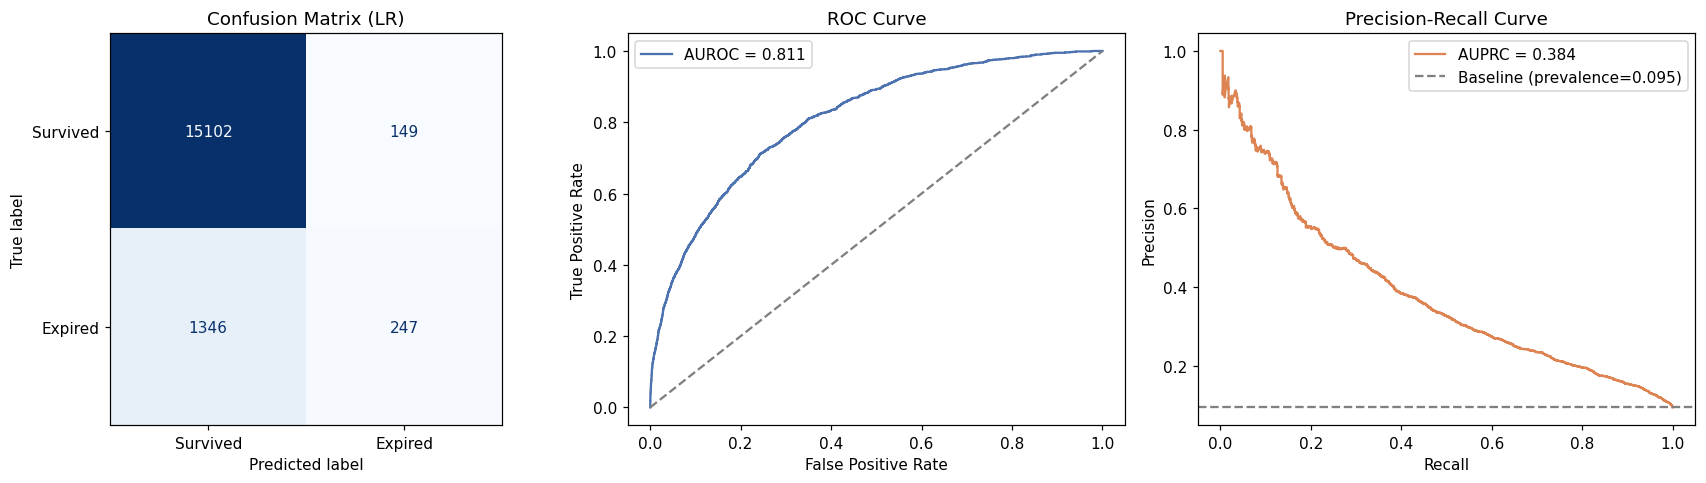

In [17]:

# Confusion matrix, ROC curve, PR curve for the WINNING model (update `winning_model_name` once chosen)
winning_model_name = "LR"  # <-- set based on the summary table + Wilcoxon results above
probs, labels = phaseA_probs[winning_model_name]
preds = (probs >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm, display_labels=["Survived", "Expired"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix ({winning_model_name})")

fpr, tpr, _ = roc_curve(labels, probs)
axes[1].plot(fpr, tpr, color="#4C72B0", label=f"AUROC = {roc_auc_score(labels, probs):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()

precision, recall, _ = precision_recall_curve(labels, probs)
axes[2].plot(recall, precision, color="#DD8452", label=f"AUPRC = {average_precision_score(labels, probs):.3f}")
axes[2].axhline(labels.mean(), linestyle="--", color="gray", label=f"Baseline (prevalence={labels.mean():.3f})")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve"); axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / f"phaseA_{winning_model_name}_diagnostics.png", bbox_inches="tight")
plt.show()


## 7. Phase B: Class Imbalance Handling

Applied to the winning architecture from Phase A. Compares unweighted BCE, class-weighted BCE, and focal loss.

In [18]:

def make_class_weighted_criterion(y_train_tensor):
    n_pos = y_train_tensor.sum().item()
    n_neg = len(y_train_tensor) - n_pos
    pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(DEVICE)
    return lambda: nn.BCEWithLogitsLoss(pos_weight=pos_weight)

winning_ctor = model_ctors[winning_model_name]

configs = {
    "unweighted": lambda: nn.BCEWithLogitsLoss(),
    "class_weighted": make_class_weighted_criterion(y_train),
    "focal": lambda: FocalLoss(),
}

phaseB_results, phaseB_per_hospital = [], {}
for config_name, criterion_ctor in configs.items():
    print(f"\n=== Phase B: {config_name} ===")
    seed_metrics = []
    last_model = None
    for seed in SEEDS:
        model = train_centralized(winning_ctor, criterion_ctor, X_train, y_train, X_val, y_val, seed)
        probs, labels = get_probs_labels(model, X_test, y_test)
        m = full_metrics(probs, labels)
        m["seed"] = seed
        seed_metrics.append(m)
        print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
        last_model = model

    seed_df = pd.DataFrame(seed_metrics)
    summary = {"config": config_name}
    for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
        summary[f"{metric}_mean"] = seed_df[metric].mean()
        summary[f"{metric}_std"] = seed_df[metric].std()
    phaseB_results.append(summary)
    phaseB_per_hospital[config_name] = evaluate_per_hospital(last_model, test_df, feature_cols)

phaseB_summary_df = pd.DataFrame(phaseB_results)
phaseB_summary_df.to_csv(RESULTS_DIR / "phaseB_summary.csv", index=False)
print("\n=== Phase B Summary ===")
print(phaseB_summary_df.to_string(index=False))

print("\n=== Phase B: Wilcoxon signed-rank tests ===")
phaseB_stats = []
cfg_names = list(configs.keys())
for i in range(len(cfg_names)):
    for j in range(i + 1, len(cfg_names)):
        a = phaseB_per_hospital[cfg_names[i]].set_index("hospitalid")["auprc"]
        b = phaseB_per_hospital[cfg_names[j]].set_index("hospitalid")["auprc"]
        common = a.index.intersection(b.index)
        stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
        phaseB_stats.append({"comparison": f"{cfg_names[i]} vs {cfg_names[j]}", "W": stat, "p_value": p,
                              "effect_size_r": r, "n_hospitals": len(common)})
        print(f"  {cfg_names[i]} vs {cfg_names[j]}: W={stat:.2f}, p={p:.6f}, r={r:.3f}")

pd.DataFrame(phaseB_stats).to_csv(RESULTS_DIR / "phaseB_wilcoxon.csv", index=False)



=== Phase B: unweighted ===
  seed 42: AUPRC=0.3849 AUROC=0.8103 F1=0.2589
  seed 43: AUPRC=0.3833 AUROC=0.8108 F1=0.2496
  seed 44: AUPRC=0.3824 AUROC=0.8103 F1=0.2481
  seed 45: AUPRC=0.3819 AUROC=0.8110 F1=0.2577
  seed 46: AUPRC=0.3844 AUROC=0.8105 F1=0.2484

=== Phase B: class_weighted ===
  seed 42: AUPRC=0.3765 AUROC=0.8130 F1=0.3547
  seed 43: AUPRC=0.3667 AUROC=0.8118 F1=0.3495
  seed 44: AUPRC=0.3720 AUROC=0.8125 F1=0.3507
  seed 45: AUPRC=0.3726 AUROC=0.8136 F1=0.3519
  seed 46: AUPRC=0.3736 AUROC=0.8123 F1=0.3522

=== Phase B: focal ===
  seed 42: AUPRC=0.3725 AUROC=0.8060 F1=0.3949
  seed 43: AUPRC=0.3718 AUROC=0.8063 F1=0.3905
  seed 44: AUPRC=0.3777 AUROC=0.8119 F1=0.3976
  seed 45: AUPRC=0.3710 AUROC=0.8089 F1=0.3851
  seed 46: AUPRC=0.3769 AUROC=0.8068 F1=0.3905

=== Phase B Summary ===
        config  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  auroc_mean  auroc_std  auprc_mean  auprc_std
    unweighted      

## 7a. Multiplicity Correction for Phase A and Phase B

In [20]:
def holm_correction(pvals, alpha=0.05):
    order = np.argsort(pvals)
    n = len(pvals)
    adjusted = np.empty(n)
    running_max = 0
    for rank, idx in enumerate(order):
        adj = (n - rank) * pvals[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)
    significant = adjusted < alpha
    return adjusted, significant

In [21]:
phaseA_stats_df = pd.DataFrame(phaseA_stats)
phaseA_stats_df["p_value_holm"], phaseA_stats_df["significant_holm"] = holm_correction(phaseA_stats_df["p_value"].values)
phaseA_stats_df.to_csv(RESULTS_DIR / "phaseA_wilcoxon_holm.csv", index=False)
print("=== Phase A (architecture, 6 comparisons) ===")
print(phaseA_stats_df[["comparison", "p_value", "p_value_holm", "significant_holm"]].to_string(index=False))

phaseB_stats_df = pd.DataFrame(phaseB_stats)
phaseB_stats_df["p_value_holm"], phaseB_stats_df["significant_holm"] = holm_correction(phaseB_stats_df["p_value"].values)
phaseB_stats_df.to_csv(RESULTS_DIR / "phaseB_wilcoxon_holm.csv", index=False)
print("\n=== Phase B (class imbalance, 3 comparisons) ===")
print(phaseB_stats_df[["comparison", "p_value", "p_value_holm", "significant_holm"]].to_string(index=False))

=== Phase A (architecture, 6 comparisons) ===
            comparison      p_value  p_value_holm  significant_holm
             LR vs MLP 1.189298e-01  2.378596e-01             False
       LR vs CNN_light 1.087953e-14  4.351813e-14              True
       LR vs CNN_heavy 1.644700e-14  4.934101e-14              True
      MLP vs CNN_light 5.247562e-16  3.148537e-15              True
      MLP vs CNN_heavy 7.844482e-16  3.922241e-15              True
CNN_light vs CNN_heavy 1.290645e-01  2.378596e-01             False

=== Phase B (class imbalance, 3 comparisons) ===
                  comparison  p_value  p_value_holm  significant_holm
unweighted vs class_weighted 0.008162      0.024485              True
         unweighted vs focal 0.031750      0.063499             False
     class_weighted vs focal 0.546192      0.546192             False


## 8. Phase C: Centralized vs. FedAvg vs. FedProx (Natural Conditions)

Uses the winning architecture (Phase A) and winning loss (Phase B). Every client is one of the qualifying hospitals, full participation, `NUM_ROUNDS=60` -- the same budget used in Phase D, so no confound between natural and stress conditions.

In [22]:

winning_criterion_name = "focal"  # <-- set based on Phase B results above
winning_criterion_ctor = configs[winning_criterion_name]

client_loaders = build_client_loaders(train_df, feature_cols)
print(f"Number of FL clients (hospitals): {len(client_loaders)}")

phaseC_results, phaseC_per_hospital = [], {}
fl_settings = {"centralized": None, "fedavg": 0.0, "fedprox": FEDPROX_MU}

for setting_name, mu in fl_settings.items():
    print(f"\n=== Phase C: {setting_name} ===")
    seed_metrics = []
    last_model = None
    for seed in SEEDS:
        if setting_name == "centralized":
            model = train_centralized(winning_ctor, winning_criterion_ctor, X_train, y_train, X_val, y_val, seed)
        else:
            model = train_federated(winning_ctor, winning_criterion_ctor, client_loaders, X_val, y_val, seed, mu=mu)
        probs, labels = get_probs_labels(model, X_test, y_test)
        m = full_metrics(probs, labels)
        m["seed"] = seed
        seed_metrics.append(m)
        print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
        last_model = model

    seed_df = pd.DataFrame(seed_metrics)
    summary = {"setting": setting_name}
    for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
        summary[f"{metric}_mean"] = seed_df[metric].mean()
        summary[f"{metric}_std"] = seed_df[metric].std()
    phaseC_results.append(summary)
    phaseC_per_hospital[setting_name] = evaluate_per_hospital(last_model, test_df, feature_cols)
    phaseC_per_hospital[setting_name].to_csv(RESULTS_DIR / f"per_hospital_{setting_name}.csv", index=False)

phaseC_summary_df = pd.DataFrame(phaseC_results)
phaseC_summary_df.to_csv(RESULTS_DIR / "phaseC_summary.csv", index=False)
print("\n=== Phase C Summary ===")
print(phaseC_summary_df.to_string(index=False))


Number of FL clients (hospitals): 94

=== Phase C: centralized ===
  seed 42: AUPRC=0.3725 AUROC=0.8060 F1=0.3949
  seed 43: AUPRC=0.3718 AUROC=0.8063 F1=0.3905
  seed 44: AUPRC=0.3777 AUROC=0.8119 F1=0.3976
  seed 45: AUPRC=0.3710 AUROC=0.8089 F1=0.3851
  seed 46: AUPRC=0.3769 AUROC=0.8068 F1=0.3905

=== Phase C: fedavg ===
  seed 42: AUPRC=0.3560 AUROC=0.8020 F1=0.3678
  seed 43: AUPRC=0.3552 AUROC=0.8031 F1=0.3612
  seed 44: AUPRC=0.3636 AUROC=0.8049 F1=0.3734
  seed 45: AUPRC=0.3612 AUROC=0.8042 F1=0.3710
  seed 46: AUPRC=0.3602 AUROC=0.8030 F1=0.3705

=== Phase C: fedprox ===
  seed 42: AUPRC=0.3549 AUROC=0.8010 F1=0.3677
  seed 43: AUPRC=0.3541 AUROC=0.8021 F1=0.3606
  seed 44: AUPRC=0.3626 AUROC=0.8040 F1=0.3722
  seed 45: AUPRC=0.3601 AUROC=0.8033 F1=0.3687
  seed 46: AUPRC=0.3590 AUROC=0.8020 F1=0.3694

=== Phase C Summary ===
    setting  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  auroc_mean  auroc_std  auprc_mean  a

In [23]:

print("=== Phase C: Wilcoxon signed-rank tests ===")
phaseC_stats = []
setting_names = list(fl_settings.keys())
for i in range(len(setting_names)):
    for j in range(i + 1, len(setting_names)):
        a = phaseC_per_hospital[setting_names[i]].set_index("hospitalid")["auprc"]
        b = phaseC_per_hospital[setting_names[j]].set_index("hospitalid")["auprc"]
        common = a.index.intersection(b.index)
        stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
        phaseC_stats.append({"comparison": f"{setting_names[i]} vs {setting_names[j]}", "W": stat,
                              "p_value": p, "effect_size_r": r, "n_hospitals": len(common)})
        print(f"  {setting_names[i]} vs {setting_names[j]}: W={stat:.2f}, p={p:.6f}, r={r:.3f}")

pd.DataFrame(phaseC_stats).to_csv(RESULTS_DIR / "phaseC_wilcoxon.csv", index=False)


=== Phase C: Wilcoxon signed-rank tests ===
  centralized vs fedavg: W=1352.00, p=0.000899, r=0.342
  centralized vs fedprox: W=1251.00, p=0.000215, r=0.382
  fedavg vs fedprox: W=998.00, p=0.000278, r=0.375


In [24]:

# Communication overhead and inference latency (for the deployed federated model)
print("=== Communication overhead ===")
n_clients = len(client_loaders)
comm_rows = []
for setting_name in ["fedavg", "fedprox"]:
    model_size_mb, per_round_mb, total_mb = communication_overhead_mb(winning_ctor(), n_clients, NUM_ROUNDS)
    comm_rows.append({"setting": setting_name, "model_size_MB": model_size_mb,
                       "per_round_MB": per_round_mb, "total_MB_full_budget": total_mb,
                       "n_clients": n_clients, "n_rounds": NUM_ROUNDS})
comm_df = pd.DataFrame(comm_rows)
comm_df.to_csv(RESULTS_DIR / "communication_overhead.csv", index=False)
print(comm_df.to_string(index=False))

print("\n=== Inference latency (CPU) ===")
cpu_model = copy.deepcopy(last_model).to("cpu")
single_ms, batch_ms = measure_latency(cpu_model, X_test.to("cpu"))
latency_df = pd.DataFrame([{"single_sample_ms": single_ms, "batch_256_ms": batch_ms,
                            "batch_256_per_sample_ms": batch_ms / 256}])
latency_df.to_csv(RESULTS_DIR / "latency.csv", index=False)
print(latency_df.to_string(index=False))


=== Communication overhead ===
setting  model_size_MB  per_round_MB  total_MB_full_budget  n_clients  n_rounds
 fedavg       0.001568      0.294784              17.68704         94        60
fedprox       0.001568      0.294784              17.68704         94        60

=== Inference latency (CPU) ===
 single_sample_ms  batch_256_ms  batch_256_per_sample_ms
         0.037557      0.060186                 0.000235


## 8a. FedProx µ Sensitivity Sweep

Tests whether the FedAvg/FedProx equivalence under natural conditions (Section 5, p=0.0003 at µ=0.01) is sensitive to the proximal-term weight, using a 3-point sweep
around the value used throughout the study. µ=0.01 duplicates Phase C's FedProx run;
only µ=0.001 and µ=0.1 require new training.

In [25]:
mu_values = [0.001, 0.01, 0.1]
mu_sweep_rows, mu_sweep_per_hospital = [], {}

for mu in mu_values:
    print(f"\n=== FedProx sweep: mu={mu} ===")
    seed_metrics = []
    last_model = None
    for seed in SEEDS:
        model = train_federated(winning_ctor, winning_criterion_ctor, client_loaders, X_val, y_val, seed, mu=mu)
        probs, labels = get_probs_labels(model, X_test, y_test)
        m = full_metrics(probs, labels)
        m["seed"] = seed
        seed_metrics.append(m)
        print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
        last_model = model
    seed_df = pd.DataFrame(seed_metrics)
    row = {"mu": mu}
    for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
        row[f"{metric}_mean"] = seed_df[metric].mean()
        row[f"{metric}_std"] = seed_df[metric].std()
    mu_sweep_rows.append(row)
    mu_sweep_per_hospital[mu] = evaluate_per_hospital(last_model, test_df, feature_cols)

mu_sweep_df = pd.DataFrame(mu_sweep_rows)
mu_sweep_df.to_csv(RESULTS_DIR / "fedprox_mu_sweep.csv", index=False)
print("\n", mu_sweep_df.to_string(index=False))

# Each mu vs. FedAvg (mu=0.0) baseline from Phase C
print("\n=== mu vs. FedAvg baseline (paired Wilcoxon, AUPRC) ===")
mu_stats = []
fedavg_baseline = phaseC_per_hospital["fedavg"].set_index("hospitalid")["auprc"]
for mu, df_h in mu_sweep_per_hospital.items():
    a = df_h.set_index("hospitalid")["auprc"]
    common = a.index.intersection(fedavg_baseline.index)
    stat, p, r = wilcoxon_effect_size(a.loc[common], fedavg_baseline.loc[common])
    mu_stats.append({"mu": mu, "W": stat, "p_value": p, "effect_size_r": r, "n": len(common)})
    print(f"  mu={mu}: W={stat:.2f}, p={p:.4f}, r={r:.3f}")
pd.DataFrame(mu_stats).to_csv(RESULTS_DIR / "fedprox_mu_sweep_wilcoxon.csv", index=False)


=== FedProx sweep: mu=0.001 ===
  seed 42: AUPRC=0.3559 AUROC=0.8019 F1=0.3681
  seed 43: AUPRC=0.3550 AUROC=0.8029 F1=0.3606
  seed 44: AUPRC=0.3635 AUROC=0.8047 F1=0.3729
  seed 45: AUPRC=0.3610 AUROC=0.8041 F1=0.3710
  seed 46: AUPRC=0.3601 AUROC=0.8028 F1=0.3705

=== FedProx sweep: mu=0.01 ===
  seed 42: AUPRC=0.3549 AUROC=0.8010 F1=0.3677
  seed 43: AUPRC=0.3541 AUROC=0.8021 F1=0.3606
  seed 44: AUPRC=0.3626 AUROC=0.8040 F1=0.3722
  seed 45: AUPRC=0.3601 AUROC=0.8033 F1=0.3687
  seed 46: AUPRC=0.3590 AUROC=0.8020 F1=0.3694

=== FedProx sweep: mu=0.1 ===
  seed 42: AUPRC=0.3462 AUROC=0.7952 F1=0.3601
  seed 43: AUPRC=0.3450 AUROC=0.7962 F1=0.3503
  seed 44: AUPRC=0.3539 AUROC=0.7984 F1=0.3627
  seed 45: AUPRC=0.3514 AUROC=0.7979 F1=0.3601
  seed 46: AUPRC=0.3512 AUROC=0.7967 F1=0.3615

    mu  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  auroc_mean  auroc_std  auprc_mean  auprc_std
0.001       0.893113      0.000875        

## 8b. Bootstrap CIs for Phase B and Phase C Equivalence Claims

In [26]:
def bootstrap_ci_gap(per_hospital_a, per_hospital_b, n_boot=10_000, margin=0.02, seed=0):
    a = per_hospital_a.set_index("hospitalid")["auprc"]
    b = per_hospital_b.set_index("hospitalid")["auprc"]
    common = a.index.intersection(b.index)
    diffs = (a.loc[common] - b.loc[common]).values
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(n_boot)
    ])
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    equivalent = (ci_low > -margin) and (ci_high < margin)
    return {"mean_gap": diffs.mean(), "ci_low": ci_low, "ci_high": ci_high,
            "n": len(diffs), "equivalent_within_margin": equivalent}

bootstrap_rows = []

# Phase B: loss configuration comparisons
for name_a, name_b in [("unweighted", "class_weighted"), ("unweighted", "focal"), ("class_weighted", "focal")]:
    res = bootstrap_ci_gap(phaseB_per_hospital[name_a], phaseB_per_hospital[name_b])
    res["comparison"] = f"{name_a} - {name_b}"
    bootstrap_rows.append(res)

# Phase C: centralized vs. federated comparisons
for name_a, name_b in [("centralized", "fedavg"), ("centralized", "fedprox"), ("fedavg", "fedprox")]:
    res = bootstrap_ci_gap(phaseC_per_hospital[name_a], phaseC_per_hospital[name_b])
    res["comparison"] = f"{name_a} - {name_b}"
    bootstrap_rows.append(res)

bootstrap_df = pd.DataFrame(bootstrap_rows)[["comparison", "mean_gap", "ci_low", "ci_high", "n", "equivalent_within_margin"]]
bootstrap_df.to_csv(RESULTS_DIR / "phaseB_phaseC_bootstrap_ci.csv", index=False)
print(bootstrap_df.to_string(index=False))

                 comparison  mean_gap    ci_low  ci_high  n  equivalent_within_margin
unweighted - class_weighted  0.007864  0.002610 0.013275 94                      True
         unweighted - focal  0.005971 -0.001491 0.012983 94                      True
     class_weighted - focal -0.001893 -0.009674 0.005782 94                      True
       centralized - fedavg  0.019647  0.008006 0.031776 94                     False
      centralized - fedprox  0.022135  0.010540 0.034278 94                     False
           fedavg - fedprox  0.002488  0.001067 0.004179 94                      True


## 9. Phase D: Robustness Stress-Test (Core Contribution)

Label noise, input noise, and Byzantine attacks, crossed with FedAvg and FedProx. Same `NUM_ROUNDS=60` budget as Phase C, so Phase C's `fedavg`/`fedprox` results (severity=0) serve directly as the fair, same-budget baseline -- no separate control run needed.

A single norm-matched random-update attack does not represent the general space of Byzantine behavior, so Byzantine attacks are evaluated under three distinct, precisely-named attack models:
- `byzantine_random_norm_matched`: a random update direction, scaled to match the mean norm of legitimate updates.
- `byzantine_sign_flip`: the malicious hospital trains honestly, then submits the negated update.
- `byzantine_scaled_replacement`: the malicious hospital trains honestly, then amplifies its own update by `BYZANTINE_BOOST_FACTOR` to try to dominate the aggregate.


In [42]:

phaseD_results, phaseD_per_hospital, phaseD_probs, phaseD_val_probs = [], {}, {}, {}
perturbation_configs = (
    [("label_noise", s) for s in LABEL_NOISE_SEVERITIES]
    + [("input_noise", s) for s in INPUT_NOISE_SEVERITIES]
    + [(f"byzantine_{atk}", s) for atk in BYZANTINE_ATTACK_TYPES for s in BYZANTINE_SEVERITIES]
)
all_hospital_ids = sorted(train_df["hospitalid"].unique())

for pert_type, severity in perturbation_configs:
    for agg_name, mu in [("fedavg", 0.0), ("fedprox", FEDPROX_MU)]:
        key = (pert_type, severity, agg_name)
        print(f"\n=== {pert_type} severity={severity} | {agg_name} ===")
        seed_metrics = []
        last_model = None
        for seed in SEEDS:
            byzantine_ids = frozenset()
            attack_type = "random_norm_matched"
            if pert_type == "label_noise":
                loaders = build_client_loaders(train_df, feature_cols, label_noise_severity=severity, seed=seed)
            elif pert_type == "input_noise":
                loaders = build_client_loaders(train_df, feature_cols, input_noise_sigma=severity, seed=seed)
            elif pert_type.startswith("byzantine_"):
                attack_type = pert_type[len("byzantine_"):]
                loaders = build_client_loaders(train_df, feature_cols, seed=seed)
                rng = np.random.default_rng(seed + 2000)
                n_byz = max(1, int(severity * len(all_hospital_ids)))
                byzantine_ids = frozenset(rng.choice(all_hospital_ids, size=n_byz, replace=False))
            else:
                raise ValueError(f"Unknown perturbation type: {pert_type}")

            model = train_federated(winning_ctor, winning_criterion_ctor, loaders, X_val, y_val, seed,
                                     mu=mu, byzantine_hospital_ids=byzantine_ids,
                                     attack_type=attack_type, boost_factor=BYZANTINE_BOOST_FACTOR)
            probs, labels = get_probs_labels(model, X_test, y_test)
            m = full_metrics(probs, labels)
            m["seed"] = seed
            seed_metrics.append(m)
            print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
            last_model = model

        seed_df = pd.DataFrame(seed_metrics)
        summary = {"perturbation": pert_type, "severity": severity, "aggregator": agg_name}
        for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
            summary[f"{metric}_mean"] = seed_df[metric].mean()
            summary[f"{metric}_std"] = seed_df[metric].std()
        phaseD_results.append(summary)
        phaseD_per_hospital[key] = evaluate_per_hospital(last_model, test_df, feature_cols)
        phaseD_probs[key] = get_probs_labels(last_model, X_test, y_test)
        # Validation-set probs, kept separately so threshold recalibration
        # (Section 9a) can select its threshold on validation data only,
        # never on the test set it is later scored against.
        phaseD_val_probs[key] = get_probs_labels(last_model, X_val, y_val)
        phaseD_per_hospital[key].to_csv(RESULTS_DIR / f"per_hospital_{pert_type}_sev{severity}_{agg_name}.csv", index=False)

phaseD_summary_df = pd.DataFrame(phaseD_results)
phaseD_summary_df.to_csv(RESULTS_DIR / "phaseD_summary.csv", index=False)
print("\n=== Phase D Summary ===")
print(phaseD_summary_df.to_string(index=False))



=== label_noise severity=0.1 | fedavg ===
  seed 42: AUPRC=0.3462 AUROC=0.7894 F1=0.3801
  seed 43: AUPRC=0.3544 AUROC=0.7931 F1=0.3733
  seed 44: AUPRC=0.3622 AUROC=0.7969 F1=0.3838
  seed 45: AUPRC=0.3560 AUROC=0.7920 F1=0.3738
  seed 46: AUPRC=0.3565 AUROC=0.7912 F1=0.3805

=== label_noise severity=0.1 | fedprox ===
  seed 42: AUPRC=0.3456 AUROC=0.7889 F1=0.3790
  seed 43: AUPRC=0.3541 AUROC=0.7925 F1=0.3734
  seed 44: AUPRC=0.3618 AUROC=0.7963 F1=0.3839
  seed 45: AUPRC=0.3555 AUROC=0.7914 F1=0.3728
  seed 46: AUPRC=0.3560 AUROC=0.7907 F1=0.3785

=== label_noise severity=0.2 | fedavg ===
  seed 42: AUPRC=0.3256 AUROC=0.7661 F1=0.2752
  seed 43: AUPRC=0.3341 AUROC=0.7707 F1=0.2790
  seed 44: AUPRC=0.3416 AUROC=0.7739 F1=0.2799
  seed 45: AUPRC=0.3334 AUROC=0.7745 F1=0.2829
  seed 46: AUPRC=0.3395 AUROC=0.7696 F1=0.2791

=== label_noise severity=0.2 | fedprox ===
  seed 42: AUPRC=0.3253 AUROC=0.7657 F1=0.2743
  seed 43: AUPRC=0.3339 AUROC=0.7703 F1=0.2785
  seed 44: AUPRC=0.3414 AUR


=== byzantine_sign_flip severity=0.2 | fedprox ===
  seed 42: AUPRC=0.3100 AUROC=0.7770 F1=0.3493
  seed 43: AUPRC=0.2534 AUROC=0.7403 F1=0.3058
  seed 44: AUPRC=0.3448 AUROC=0.7967 F1=0.3605
  seed 45: AUPRC=0.3357 AUROC=0.7861 F1=0.3613
  seed 46: AUPRC=0.3062 AUROC=0.7725 F1=0.3235

=== byzantine_scaled_replacement severity=0.05 | fedavg ===
  seed 42: AUPRC=0.3550 AUROC=0.8005 F1=0.3582
  seed 43: AUPRC=0.3519 AUROC=0.7966 F1=0.3654
  seed 44: AUPRC=0.3571 AUROC=0.7961 F1=0.3708
  seed 45: AUPRC=0.3503 AUROC=0.7942 F1=0.3674
  seed 46: AUPRC=0.3506 AUROC=0.7956 F1=0.3548

=== byzantine_scaled_replacement severity=0.05 | fedprox ===
  seed 42: AUPRC=0.3540 AUROC=0.7995 F1=0.3577
  seed 43: AUPRC=0.3510 AUROC=0.7955 F1=0.3644
  seed 44: AUPRC=0.3567 AUROC=0.7953 F1=0.3719
  seed 45: AUPRC=0.3493 AUROC=0.7934 F1=0.3643
  seed 46: AUPRC=0.3498 AUROC=0.7946 F1=0.3568

=== byzantine_scaled_replacement severity=0.1 | fedavg ===
  seed 42: AUPRC=0.2691 AUROC=0.7464 F1=0.3266
  seed 43: AU

In [43]:

# Statistical tests: vs. Phase C baseline (same budget, so no confound), and fedavg vs. fedprox per condition
print("=== Phase D: Statistical tests ===")
phaseD_stats = []
for (pert_type, severity, agg_name), df_h in phaseD_per_hospital.items():
    baseline_df = phaseC_per_hospital.get(agg_name)
    if baseline_df is None:
        continue
    a = df_h.set_index("hospitalid")["auprc"]
    b = baseline_df.set_index("hospitalid")["auprc"]
    common = a.index.intersection(b.index)
    if len(common) < 5:
        continue
    stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
    phaseD_stats.append({"comparison": f"{pert_type}_sev{severity}_{agg_name} vs baseline_{agg_name}",
                          "W": stat, "p_value": p, "effect_size_r": r, "n_hospitals": len(common)})

for pert_type, severity in {(k[0], k[1]) for k in phaseD_per_hospital}:
    key_avg, key_prox = (pert_type, severity, "fedavg"), (pert_type, severity, "fedprox")
    if key_avg not in phaseD_per_hospital or key_prox not in phaseD_per_hospital:
        continue
    a = phaseD_per_hospital[key_avg].set_index("hospitalid")["auprc"]
    b = phaseD_per_hospital[key_prox].set_index("hospitalid")["auprc"]
    common = a.index.intersection(b.index)
    if len(common) < 5:
        continue
    stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
    phaseD_stats.append({"comparison": f"fedavg vs fedprox @ {pert_type}_sev{severity}",
                          "W": stat, "p_value": p, "effect_size_r": r, "n_hospitals": len(common)})

# Additional comparison: each stronger Byzantine attack vs. the original
# random_norm_matched attack, at matching severity/aggregator -- quantifies
# how much stronger sign_flip / scaled_replacement actually are.
for severity in BYZANTINE_SEVERITIES:
    for agg_name in ["fedavg", "fedprox"]:
        weak_key = ("byzantine_random_norm_matched", severity, agg_name)
        if weak_key not in phaseD_per_hospital:
            continue
        for atk in ["sign_flip", "scaled_replacement"]:
            strong_key = (f"byzantine_{atk}", severity, agg_name)
            if strong_key not in phaseD_per_hospital:
                continue
            a = phaseD_per_hospital[strong_key].set_index("hospitalid")["auprc"]
            b = phaseD_per_hospital[weak_key].set_index("hospitalid")["auprc"]
            common = a.index.intersection(b.index)
            if len(common) < 5:
                continue
            stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
            phaseD_stats.append({
                "comparison": f"byzantine_{atk}_sev{severity}_{agg_name} vs byzantine_random_norm_matched_sev{severity}_{agg_name}",
                "W": stat, "p_value": p, "effect_size_r": r, "n_hospitals": len(common)})

phaseD_stats_df = pd.DataFrame(phaseD_stats)
phaseD_stats_df.to_csv(RESULTS_DIR / "phaseD_wilcoxon.csv", index=False)
print(phaseD_stats_df.to_string(index=False))


=== Phase D: Statistical tests ===
                                                                                   comparison      W      p_value  effect_size_r  n_hospitals
                                                 label_noise_sev0.1_fedavg vs baseline_fedavg 1997.0 3.745111e-01       0.091596           94
                                               label_noise_sev0.1_fedprox vs baseline_fedprox 2164.0 7.961684e-01       0.026643           94
                                                 label_noise_sev0.2_fedavg vs baseline_fedavg 1337.0 7.331520e-04       0.348298           94
                                               label_noise_sev0.2_fedprox vs baseline_fedprox 1394.0 1.567280e-03       0.326128           94
                                                 label_noise_sev0.3_fedavg vs baseline_fedavg  677.0 4.472725e-09       0.605000           94
                                               label_noise_sev0.3_fedprox vs baseline_fedprox  703.0 8.038724e-09

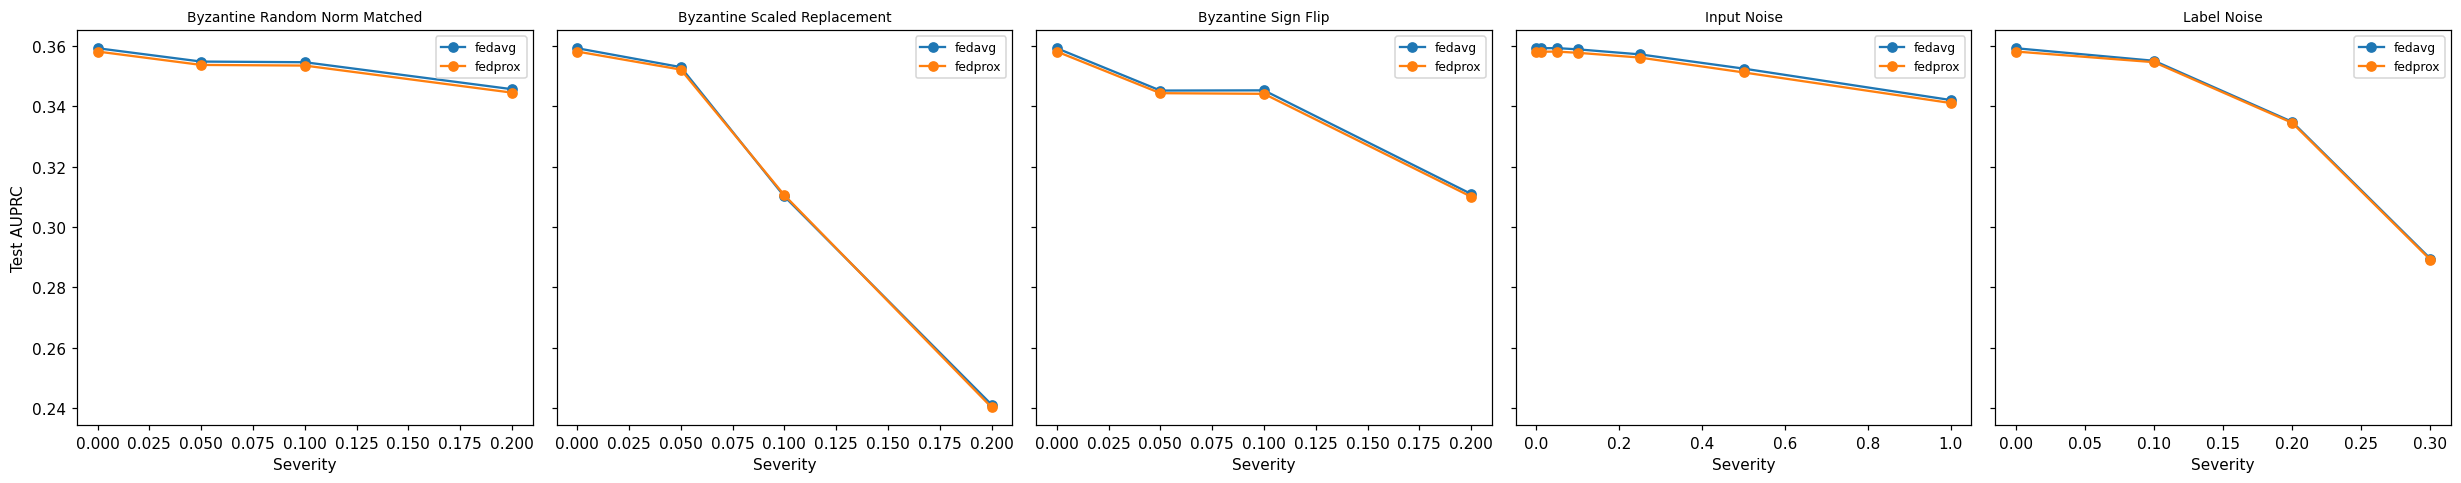

In [44]:

# Degradation curves: AUPRC vs. severity, one line per aggregator, one panel per
# perturbation type. Built dynamically from phaseD_summary_df so it automatically
# covers however many perturbation types are present (label_noise, input_noise,
# and the three named Byzantine attack variants).
pert_types = sorted(phaseD_summary_df["perturbation"].unique())
n_panels = len(pert_types)
fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 4.5), sharey=True)
if n_panels == 1:
    axes = [axes]
baseline_auprc = {agg: phaseC_summary_df.set_index("setting").loc[agg, "auprc_mean"] for agg in ["fedavg", "fedprox"]}

for ax, pert in zip(axes, pert_types):
    severities_this = sorted(phaseD_summary_df.loc[phaseD_summary_df["perturbation"] == pert, "severity"].unique())
    for agg in ["fedavg", "fedprox"]:
        xs = [0] + severities_this
        ys = [baseline_auprc[agg]] + [
            phaseD_summary_df[(phaseD_summary_df["perturbation"] == pert) &
                               (phaseD_summary_df["severity"] == s) &
                               (phaseD_summary_df["aggregator"] == agg)]["auprc_mean"].values[0]
            for s in severities_this
        ]
        ax.plot(xs, ys, marker="o", label=agg)
    ax.set_title(pert.replace("_", " ").title(), fontsize=9)
    ax.set_xlabel("Severity")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Test AUPRC")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "phaseD_degradation_curves.png", bbox_inches="tight")
plt.show()


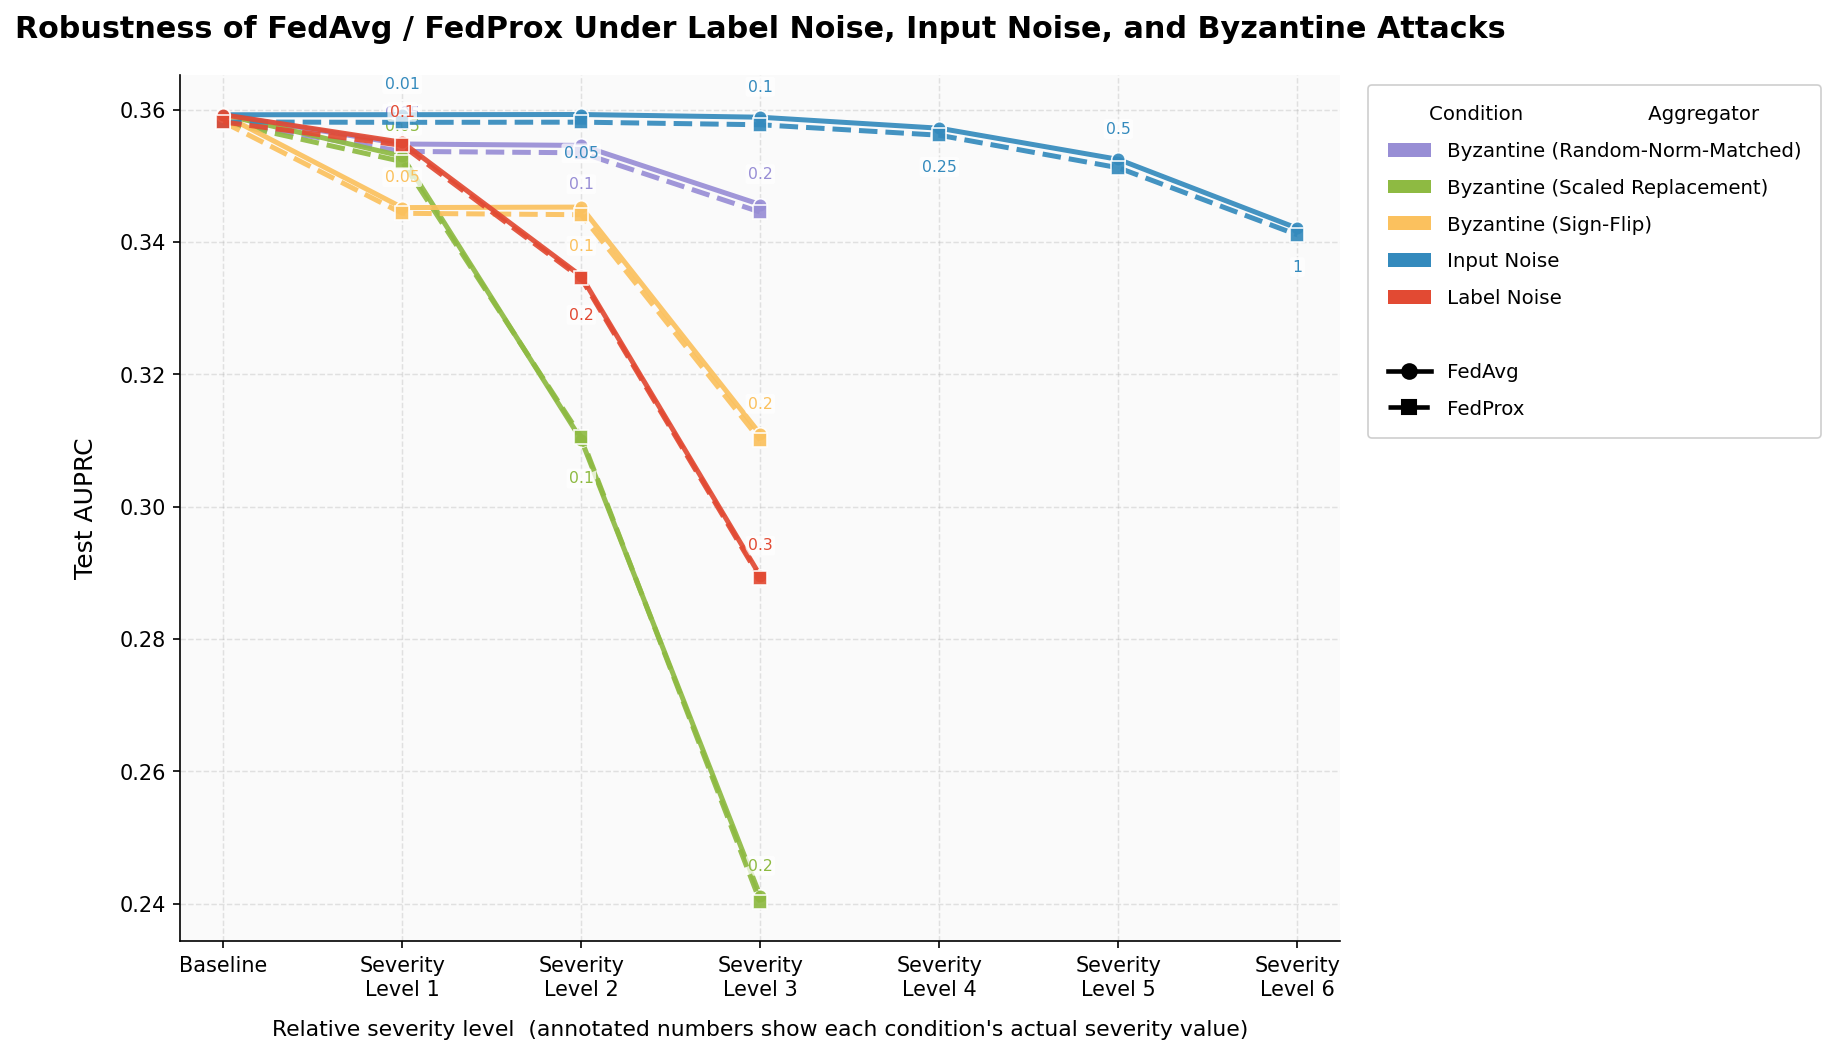

In [45]:

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams["font.family"] = "DejaVu Sans"

# A curated, distinguishable, colorblind-friendlier palette (one per perturbation type)
CUSTOM_COLORS = {
    "label_noise": "#E24A33",                       # red-orange
    "input_noise": "#348ABD",                        # blue
    "byzantine_random_norm_matched": "#988ED5",      # purple
    "byzantine_sign_flip": "#FBC15E",                # amber
    "byzantine_scaled_replacement": "#8EBA42",       # green
}
NICE_NAMES = {
    "label_noise": "Label Noise",
    "input_noise": "Input Noise",
    "byzantine_random_norm_matched": "Byzantine (Random-Norm-Matched)",
    "byzantine_sign_flip": "Byzantine (Sign-Flip)",
    "byzantine_scaled_replacement": "Byzantine (Scaled Replacement)",
}
agg_linestyle = {"fedavg": "-", "fedprox": "--"}
agg_marker = {"fedavg": "o", "fedprox": "s"}

pert_types = sorted(phaseD_summary_df["perturbation"].unique())
color_map = {p: CUSTOM_COLORS.get(p, "#333333") for p in pert_types}
baseline_auprc = {agg: phaseC_summary_df.set_index("setting").loc[agg, "auprc_mean"] for agg in ["fedavg", "fedprox"]}
max_rank = max(len(phaseD_summary_df.loc[phaseD_summary_df["perturbation"] == p, "severity"].unique())
               for p in pert_types)

fig, ax = plt.subplots(figsize=(13, 7.5), dpi=150)
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAFA")

for pert in pert_types:
    severities_this = sorted(phaseD_summary_df.loc[phaseD_summary_df["perturbation"] == pert, "severity"].unique())
    for agg in ["fedavg", "fedprox"]:
        xs = list(range(len(severities_this) + 1))
        ys = [baseline_auprc[agg]]
        for s in severities_this:
            val = phaseD_summary_df[(phaseD_summary_df["perturbation"] == pert) &
                                     (phaseD_summary_df["severity"] == s) &
                                     (phaseD_summary_df["aggregator"] == agg)]["auprc_mean"].values[0]
            ys.append(val)
        ax.plot(xs, ys, color=color_map[pert], linestyle=agg_linestyle[agg], marker=agg_marker[agg],
                 linewidth=2.4, markersize=6.5, markeredgecolor="white", markeredgewidth=0.8,
                 alpha=0.92, zorder=3, solid_capstyle="round")

        # Annotate severity values on the FedAvg line only (FedProx tracks almost
        # identically, so repeating the label on both lines just adds clutter).
        if agg == "fedavg":
            for j, (x, s) in enumerate(zip(xs[1:], severities_this)):
                # alternate the vertical offset so labels on crossing lines don't collide
                offset = 11 if (j % 2 == 0) else -15
                va = "bottom" if offset > 0 else "top"
                ax.annotate(f"{s:g}", (x, ys[x]), textcoords="offset points", xytext=(0, offset),
                            fontsize=7.5, ha="center", va=va, color=color_map[pert], fontweight="medium",
                            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.75))

ax.set_xticks(range(max_rank + 1))
ax.set_xticklabels(["Baseline"] + [f"Severity\nLevel {i}" for i in range(1, max_rank + 1)], fontsize=10)
ax.set_xlabel("Relative severity level  (annotated numbers show each condition's actual severity value)",
              fontsize=10.5, labelpad=10)
ax.set_ylabel("Test AUPRC", fontsize=12, labelpad=10)
ax.set_title("Robustness of FedAvg / FedProx Under Label Noise, Input Noise, and Byzantine Attacks",
             fontsize=14.5, fontweight="bold", pad=18)
ax.grid(alpha=0.35, linestyle="--", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.margins(x=0.04)

# Single, combined legend: colored patches for perturbation type, line-style
# samples for aggregator, stacked in one legend box so nothing needs cross-referencing.
color_handles = [Patch(facecolor=color_map[p], edgecolor="none", label=NICE_NAMES.get(p, p))
                  for p in pert_types]
spacer = Line2D([0], [0], color="none", label="")
style_handles = [Line2D([0], [0], color="black", lw=2.2, linestyle=agg_linestyle[a], marker=agg_marker[a],
                          markersize=7, label=("FedAvg" if a == "fedavg" else "FedProx"))
                  for a in ["fedavg", "fedprox"]]

legend = ax.legend(handles=color_handles + [spacer] + style_handles,
                    loc="upper left", bbox_to_anchor=(1.015, 1.0), fontsize=9.5,
                    frameon=True, framealpha=0.95, edgecolor="#CCCCCC",
                    title="Condition                    Aggregator", title_fontsize=9.5,
                    handlelength=2.2, labelspacing=0.9, borderpad=1.0)
legend.get_frame().set_linewidth(0.8)

# Reserve room for the legend explicitly, THEN save with tight bbox as a safety net --
# this combination is what prevents the legend from being clipped in the exported file.
fig.subplots_adjust(right=0.72)
plt.savefig(FIGURE_DIR / "phaseD_degradation_combined.png", dpi=300, bbox_inches="tight", pad_inches=0.35,
            facecolor="white")
plt.show()


### 9a. Threshold Recalibration Check at Label Noise

Tests whether the accuracy/recall collapse at label noise is a genuine ranking
failure or a miscalibrated decision threshold, by sweeping the threshold post-hoc
on the already-computed predicted probabilities. No retraining required.

In [46]:
from sklearn.metrics import f1_score, accuracy_score, brier_score_loss


def expected_calibration_error(labels, probs, n_bins=10):
    """Standard ECE: bin predicted probabilities, compare mean predicted
    probability to observed frequency within each bin, weight by bin size."""
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        in_bin = (probs > lo) & (probs <= hi) if i > 0 else (probs >= lo) & (probs <= hi)
        if in_bin.sum() == 0:
            continue
        bin_acc = labels[in_bin].mean()
        bin_conf = probs[in_bin].mean()
        ece += (in_bin.sum() / len(probs)) * abs(bin_acc - bin_conf)
    return ece

# IMPORTANT: the decision threshold is selected on VALIDATION-set predictions
# ONLY (phaseD_val_probs), then frozen and applied exactly once to the
# held-out test set (phaseD_probs). Selecting the threshold directly on
# test-set F1 would be test-set leakage and would overestimate the
# reported recovery.

thresholds = np.linspace(0.01, 0.99, 99)
recal_rows = []
for severity in LABEL_NOISE_SEVERITIES:  # 0.10, 0.20, 0.30
    for agg_name in ["fedavg", "fedprox"]:
        key = ("label_noise", severity, agg_name)
        val_probs, val_labels = phaseD_val_probs[key]
        test_probs, test_labels = phaseD_probs[key]

        # --- Select threshold on VALIDATION data only ---
        best_val_f1, best_thr = -1, 0.5
        for t in thresholds:
            val_preds = (val_probs >= t).astype(int)
            f1 = f1_score(val_labels, val_preds, zero_division=0)
            if f1 > best_val_f1:
                best_val_f1, best_thr = f1, t

        # --- Freeze that threshold, apply ONCE to the test set ---
        default_preds = (test_probs >= 0.5).astype(int)
        recal_preds = (test_probs >= best_thr).astype(int)

        default_f1 = f1_score(test_labels, default_preds, zero_division=0)
        default_acc = accuracy_score(test_labels, default_preds)
        recal_f1 = f1_score(test_labels, recal_preds, zero_division=0)
        recal_acc = accuracy_score(test_labels, recal_preds)

        # Calibration metrics: threshold improvement alone does not establish
        # probability calibration, so report Brier score AND ECE alongside it.
        brier = brier_score_loss(test_labels, test_probs)
        ece = expected_calibration_error(test_labels, test_probs, n_bins=10)

        recal_rows.append({
            "severity": severity,
            "aggregator": agg_name,
            "accuracy_at_0.5": default_acc,
            "f1_at_0.5": default_f1,
            "best_threshold_from_VALIDATION": best_thr,
            "val_f1_at_best_threshold": best_val_f1,
            "test_f1_at_best_threshold": recal_f1,
            "test_accuracy_at_best_threshold": recal_acc,
            "test_brier_score": brier,
            "test_ece": ece,
        })

recal_df = pd.DataFrame(recal_rows)
recal_df.to_csv(RESULTS_DIR / "label_noise_threshold_recalibration.csv", index=False)
print(recal_df.to_string(index=False))


 severity aggregator  accuracy_at_0.5  f1_at_0.5  best_threshold_from_VALIDATION  val_f1_at_best_threshold  test_f1_at_best_threshold  test_accuracy_at_best_threshold  test_brier_score  test_ece
      0.1     fedavg         0.853242   0.380451                            0.51                  0.393611                   0.377110                         0.870755          0.201004  0.352178
      0.1    fedprox         0.852588   0.378473                            0.51                  0.391329                   0.376430                         0.870577          0.201152  0.352440
      0.2     fedavg         0.619687   0.279091                            0.54                  0.376261                   0.362757                         0.874852          0.242846  0.403800
      0.2    fedprox         0.619508   0.278997                            0.54                  0.375520                   0.364463                         0.875564          0.242916  0.403798
      0.3     fedavg     

### 9b. Holm–Bonferroni Correction Across All Phase D Tests


In [47]:
pvals = phaseD_stats_df["p_value"].values
adj_p, sig_holm = holm_correction(pvals)
phaseD_stats_df["p_value_holm"] = adj_p
phaseD_stats_df["significant_holm"] = sig_holm
phaseD_stats_df.to_csv(RESULTS_DIR / "phaseD_wilcoxon_holm.csv", index=False)
print(phaseD_stats_df[["comparison", "p_value", "p_value_holm", "significant_holm"]].to_string(index=False))

                                                                                   comparison      p_value  p_value_holm  significant_holm
                                                 label_noise_sev0.1_fedavg vs baseline_fedavg 3.745111e-01  1.000000e+00             False
                                               label_noise_sev0.1_fedprox vs baseline_fedprox 7.961684e-01  1.000000e+00             False
                                                 label_noise_sev0.2_fedavg vs baseline_fedavg 7.331520e-04  3.519130e-02              True
                                               label_noise_sev0.2_fedprox vs baseline_fedprox 1.567280e-03  6.425848e-02             False
                                                 label_noise_sev0.3_fedavg vs baseline_fedavg 4.472725e-09  2.594180e-07              True
                                               label_noise_sev0.3_fedprox vs baseline_fedprox 8.038724e-09  4.582072e-07              True
                           

## 10. Hospital-Size Stratification

No new training -- pure re-analysis of Phase D's already-computed per-hospital results, checking whether small hospitals are disproportionately vulnerable to any perturbation type.

In [48]:

median_size = qualifying_hospitals["n_stays"].median()
qualifying_hospitals = qualifying_hospitals.copy()  # avoids SettingWithCopyWarning below
qualifying_hospitals["size_group"] = np.where(qualifying_hospitals["n_stays"] >= median_size, "large", "small")
size_groups = qualifying_hospitals.set_index("hospitalid")["size_group"]
print(f"Median hospital size: {median_size:.0f} stays")
print(qualifying_hospitals["size_group"].value_counts())

strat_rows = []
for (pert_type, severity, agg_name), df_h in phaseD_per_hospital.items():
    baseline_df = phaseC_per_hospital.get(agg_name)
    if baseline_df is None:
        continue
    a = df_h.set_index("hospitalid")["auprc"]
    b = baseline_df.set_index("hospitalid")["auprc"]
    common = a.index.intersection(b.index).intersection(size_groups.index)
    delta = a.loc[common] - b.loc[common]
    groups = size_groups.loc[common]
    small_delta, large_delta = delta[groups == "small"], delta[groups == "large"]
    if len(small_delta) < 5 or len(large_delta) < 5:
        continue
    stat, p = mannwhitneyu(small_delta, large_delta, alternative="two-sided")
    strat_rows.append({"perturbation": pert_type, "severity": severity, "aggregator": agg_name,
                        "small_n": len(small_delta), "small_mean_delta": small_delta.mean(),
                        "large_n": len(large_delta), "large_mean_delta": large_delta.mean(),
                        "U_stat": stat, "p_value": p})

strat_df = pd.DataFrame(strat_rows)
strat_df.to_csv(RESULTS_DIR / "hospital_size_stratification.csv", index=False)
print(strat_df.to_string(index=False))


Median hospital size: 647 stays
size_group
large    48
small    46
Name: count, dtype: int64
                 perturbation  severity aggregator  small_n  small_mean_delta  large_n  large_mean_delta  U_stat  p_value
                  label_noise      0.10     fedavg       46      6.144991e-04       48         -0.006761  1228.0 0.350249
                  label_noise      0.10    fedprox       46      4.029002e-03       48         -0.005995  1252.0 0.264579
                  label_noise      0.20     fedavg       46     -1.145392e-02       48         -0.022127  1115.0 0.936700
                  label_noise      0.20    fedprox       46     -9.197920e-03       48         -0.020717  1123.0 0.888718
                  label_noise      0.30     fedavg       46     -5.362969e-02       48         -0.081076  1309.0 0.121921
                  label_noise      0.30    fedprox       46     -5.160221e-02       48         -0.078997  1291.0 0.158359
                  input_noise      0.01     fedavg   

In [49]:
strat_df["p_value_holm"], strat_df["significant_holm"] = holm_correction(strat_df["p_value"].values)
strat_df.to_csv(RESULTS_DIR / "hospital_size_stratification_holm.csv", index=False)
print(strat_df[["perturbation", "severity", "aggregator", "p_value", "p_value_holm", "significant_holm"]].to_string(index=False))

                 perturbation  severity aggregator  p_value  p_value_holm  significant_holm
                  label_noise      0.10     fedavg 0.350249      1.000000             False
                  label_noise      0.10    fedprox 0.264579      1.000000             False
                  label_noise      0.20     fedavg 0.936700      1.000000             False
                  label_noise      0.20    fedprox 0.888718      1.000000             False
                  label_noise      0.30     fedavg 0.121921      1.000000             False
                  label_noise      0.30    fedprox 0.158359      1.000000             False
                  input_noise      0.01     fedavg 0.501966      1.000000             False
                  input_noise      0.01    fedprox 0.826809      1.000000             False
                  input_noise      0.05     fedavg 0.210644      1.000000             False
                  input_noise      0.05    fedprox 0.488862      1.000000       

## 10a. Supplementary: Hospital-Count Dose-Response, Matched to Related-Work Selection Criteria

Instead of arbitrary subsample sizes, hospitals are selected using the same inclusion
logic each related eICU-CRD study applied to its own hospital pool, run against our
already-qualifying hospital pool (which already satisfies ≥300 stays / ≥15 mortality
events, so it is a valid superset for every threshold below). Where a study's target
count exceeds what our pool actually satisfies, the achieved count is reported alongside
the target rather than forced to match. FedAvg, natural conditions, same 60-round budget,
5 seeds -- no robustness grid rerun.

In [56]:
CRITERIA_SPECS = [
    {"study": "Wang et al.",            "kind": "deaths_gt",          "param": 100, "target_n": 42},
    {"study": "Yang et al. (FedRew)",   "kind": "stays_ge",           "param": 650, "target_n": 10},
    {"study": "POLA (Deng et al.)",     "kind": "stays_ge",           "param": 600, "target_n": 12},
    {"study": "FedComDist",             "kind": "top_volume",         "param": None, "target_n": 15},
    {"study": "FedWeight",              "kind": "top_volume",         "param": None, "target_n": 10},
    {"study": "Dang et al. 2022",       "kind": "top_volume",         "param": None, "target_n": 20},
    {"study": "Dang et al. 2020",       "kind": "stays_ge_top_volume","param": 500, "target_n": 20},
    {"study": "CBFL (Huang et al.)",    "kind": "stays_gt_balanced",  "param": 600, "target_n": 50, "patients_per_client": 560},
    {"study": "FedCov",                 "kind": "random_balanced",    "param": None, "target_n": 50, "patients_per_client": 600},
    {"study": "Georgoutsos et al.",     "kind": "size_mortality_spread", "param": None, "target_n": 8},
]

def select_hospitals(hosp_df, spec, rng):
    df, kind, n_target = hosp_df, spec["kind"], spec["target_n"]
    if kind == "deaths_gt":
        pool = df[df["n_positive"] > spec["param"]]
        ids = pool.sort_values("n_stays", ascending=False)["hospitalid"].tolist()
    elif kind == "stays_ge":
        pool = df[df["n_stays"] >= spec["param"]]
        ids = pool.sort_values("n_stays", ascending=False)["hospitalid"].tolist()
    elif kind == "top_volume":
        ids = df.sort_values("n_stays", ascending=False)["hospitalid"].tolist()
    elif kind == "stays_ge_top_volume":
        pool = df[df["n_stays"] >= spec["param"]]
        ids = pool.sort_values("n_stays", ascending=False)["hospitalid"].tolist()
    elif kind in ("stays_gt_balanced", "random_balanced"):
        pool = df[df["n_stays"] > spec["param"]] if kind == "stays_gt_balanced" else df
        ids = list(rng.choice(pool["hospitalid"].values, size=min(n_target, len(pool)), replace=False))
        return ids  # already capped, don't re-trim below
    elif kind == "size_mortality_spread":
        sorted_df = df.sort_values("n_stays").reset_index(drop=True)
        idx = np.linspace(0, len(sorted_df) - 1, n_target).round().astype(int)
        return sorted_df.loc[idx, "hospitalid"].tolist()
    else:
        raise ValueError(kind)
    return ids[:n_target]  # cap to target if pool exceeds it; else use whole (undersized) pool


def build_subset_client_loaders(train_df, feat_cols, hosp_ids, cap_per_client=None, seed=42):
    loaders = {}
    for hosp_id in hosp_ids:
        group = train_df[train_df["hospitalid"] == hosp_id]
        if cap_per_client is not None and len(group) > cap_per_client:
            pos, neg = group[group["mortality_label"] == 1], group[group["mortality_label"] == 0]
            frac = cap_per_client / len(group)
            n_pos = max(1, round(len(pos) * frac))
            n_neg = max(1, cap_per_client - n_pos)
            group = pd.concat([
                pos.sample(n=min(n_pos, len(pos)), random_state=seed),
                neg.sample(n=min(n_neg, len(neg)), random_state=seed),
            ])
        X, y = to_tensors(group, feat_cols)
        loaders[hosp_id] = DataLoader(TensorDataset(X, y), batch_size=BATCH_SIZE, shuffle=True)
    return loaders


rng = np.random.default_rng(2026)
dose_response_rows = []
for spec in CRITERIA_SPECS:
    ids = select_hospitals(qualifying_hospitals, spec, rng)
    cap = spec.get("patients_per_client")
    train_cap = round(cap * TRAIN_FRAC) if cap else None
    sub_loaders = build_subset_client_loaders(train_df, feature_cols, ids, cap_per_client=train_cap)
    sub_test_df = test_df[test_df["hospitalid"].isin(ids)]
    X_sub, y_sub = to_tensors(sub_test_df, feature_cols)

    seed_metrics = []
    for seed in SEEDS:
        model = train_federated(winning_ctor, winning_criterion_ctor, sub_loaders, X_val, y_val, seed, mu=0.0)
        probs, labels = get_probs_labels(model, X_sub, y_sub)
        seed_metrics.append(full_metrics(probs, labels))
    seed_df = pd.DataFrame(seed_metrics)

    dose_response_rows.append({
        "study": spec["study"], "criterion": spec["kind"], "param": spec.get("param"),
        "target_n_hospitals": spec["target_n"], "actual_n_hospitals": len(ids),
        "auroc_mean": seed_df["auroc"].mean(), "auroc_std": seed_df["auroc"].std(),
        "auprc_mean": seed_df["auprc"].mean(), "auprc_std": seed_df["auprc"].std(),
    })
    print(f"{spec['study']:22s} target={spec['target_n']:>3} actual={len(ids):>3}  "
          f"AUPRC={seed_df['auprc'].mean():.4f}  AUROC={seed_df['auroc'].mean():.4f}")

# Reference point: full hospital pool (already computed in Phase C)
dose_response_rows.append({
    "study": "This work (full pool)", "criterion": "min-volume tier", "param": HOSPITAL_TIER,
    "target_n_hospitals": len(qualifying_hospitals), "actual_n_hospitals": len(qualifying_hospitals),
    "auroc_mean": phaseC_summary_df.set_index("setting").loc["fedavg", "auroc_mean"], "auroc_std": np.nan,
    "auprc_mean": phaseC_summary_df.set_index("setting").loc["fedavg", "auprc_mean"], "auprc_std": np.nan,
})

dose_response_df = pd.DataFrame(dose_response_rows).sort_values("actual_n_hospitals")
dose_response_df.to_csv(RESULTS_DIR / "hospital_count_dose_response.csv", index=False)
print("\n", dose_response_df.to_string(index=False))


Wang et al.            target= 42 actual= 21  AUPRC=0.3940  AUROC=0.8041
Yang et al. (FedRew)   target= 10 actual= 10  AUPRC=0.3519  AUROC=0.7989
POLA (Deng et al.)     target= 12 actual= 12  AUPRC=0.3778  AUROC=0.8061
FedComDist             target= 15 actual= 15  AUPRC=0.3686  AUROC=0.8027
FedWeight              target= 10 actual= 10  AUPRC=0.3519  AUROC=0.7989
Dang et al. 2022       target= 20 actual= 20  AUPRC=0.3652  AUROC=0.8075
Dang et al. 2020       target= 20 actual= 20  AUPRC=0.3652  AUROC=0.8075
CBFL (Huang et al.)    target= 50 actual= 50  AUPRC=0.3021  AUROC=0.7696
FedCov                 target= 50 actual= 50  AUPRC=0.2998  AUROC=0.7687
Georgoutsos et al.     target=  8 actual=  8  AUPRC=0.2506  AUROC=0.7755

                 study             criterion     param  target_n_hospitals  actual_n_hospitals  auroc_mean  auroc_std  auprc_mean  auprc_std
   Georgoutsos et al. size_mortality_spread      None                   8                   8    0.775495   0.003288    0.250623

## 10b. Supplementary: Full Unfiltered Cohort (up to 208 Hospitals)

Reruns feature extraction and FedAvg training on every hospital with at least one
qualifying patient after the age/first-stay/24h criteria -- without the
≥300-stays/≥15-mortality volume threshold used as the primary cohort. Per-hospital
robustness/stratification analyses are NOT rerun here, since many of these hospitals
have too few stays for a meaningful per-hospital statistic --
this section reports only aggregate natural-condition AUROC/AUPRC as a scale check.

In [57]:
FULL_FEATURE_DIR = BASE_DIR / "feature_output_full208"
FULL_SPLIT_DIR = BASE_DIR / "split_output_full208"
for d in [FULL_FEATURE_DIR, FULL_SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

full_qualifying_ids = set(cohort_df["hospitalid"].unique())
print(f"Full unfiltered cohort: {len(full_qualifying_ids)} hospitals, {len(cohort_df)} patients "
      f"(vs. {len(qualifying_ids)} hospitals / {len(final_cohort)} patients in the primary cohort)")

# --- Feature extraction (reuses existing functions, new stay_ids / output path) ---
full_stay_ids = set(cohort_df["patientunitstayid"])
print(f"Extracting features for {len(full_stay_ids)} patients (full cohort)...")
full_vitals_binned = extract_vitals(full_stay_ids)
full_labs_wide = extract_labs(full_stay_ids)
full_feature_df = fill_and_flatten(full_vitals_binned, full_labs_wide, full_stay_ids)
full_final_features = attach_static_and_label(full_feature_df, cohort_df)
full_final_features.to_parquet(FULL_FEATURE_DIR / "features_flat.parquet", index=False)
print(f"Saved {len(full_final_features)} patients x {full_final_features.shape[1]} columns")

# --- Split, encode, normalize (reuses existing functions) ---
df_full = pd.read_parquet(FULL_FEATURE_DIR / "features_flat.parquet")
df_full = impute_age(df_full)
df_full = encode_gender(df_full)
df_full = encode_unittype(df_full)
df_full = encode_admission_dx(df_full)

# NOTE: per-hospital stratified split (used for the primary hospital cohort) requires
# >=2 patients of each class per hospital, which the primary cohort guarantees via its
# >=300 stays / >=15 mortality threshold. The full unfiltered pool includes many small
# hospitals that violate this, so a single GLOBAL stratified split is used instead.
# This section only reports pooled (not per-hospital) metrics, so this is not a problem here.
def stratified_split_global(df, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=RANDOM_SEED):
    ids = df["patientunitstayid"].values
    labels = df["mortality_label"].values
    train_ii, temp_ii, train_lbl, temp_lbl = train_test_split(
        ids, labels, test_size=(val_frac + test_frac), stratify=labels, random_state=seed
    )
    val_ii, test_ii = train_test_split(
        temp_ii, test_size=test_frac / (val_frac + test_frac), stratify=temp_lbl, random_state=seed
    )
    return set(train_ii), set(val_ii), set(test_ii)

train_ids_f, val_ids_f, test_ids_f = stratified_split_global(df_full)
df_full["split"] = np.select(
    [df_full["patientunitstayid"].isin(train_ids_f), df_full["patientunitstayid"].isin(val_ids_f),
     df_full["patientunitstayid"].isin(test_ids_f)],
    ["train", "val", "test"], default="unassigned",
)
assert (df_full["split"] == "unassigned").sum() == 0

EXCLUDE_COLS_F = {"patientunitstayid", "hospitalid", "mortality_label", "split"}
feature_cols_full = get_feature_columns(df_full, EXCLUDE_COLS_F)
train_mask_f = df_full["split"] == "train"
df_full_norm, _ = normalize_with_sentinel_preservation(df_full, feature_cols_full, train_mask_f)

for split_name in ["train", "val", "test"]:
    split_df = df_full_norm[df_full_norm["split"] == split_name].drop(columns=["split"])
    split_df.to_parquet(FULL_SPLIT_DIR / f"{split_name}.parquet", index=False)
    print(f"{split_name}: {len(split_df)} patients, prevalence={split_df['mortality_label'].mean():.4f}")

# Flag hospitals that ended up with zero patients in the training split (expected for the
# smallest hospitals in the long tail; they simply won't contribute an FL client below).
train_df_full_check = df_full_norm[df_full_norm["split"] == "train"]
n_hosp_with_train_data = train_df_full_check["hospitalid"].nunique()
print(f"\nHospitals with >=1 training patient: {n_hosp_with_train_data} / {len(full_qualifying_ids)}")

print(f"\nFull-cohort feature dimensionality: {len(feature_cols_full)} (primary cohort used {len(feature_cols)})")

Full unfiltered cohort: 207 hospitals, 97963 patients (vs. 94 hospitals / 83909 patients in the primary cohort)
Extracting features for 97963 patients (full cohort)...
Saved 97963 patients x 367 columns
train: 68574 patients, prevalence=0.0929
val: 9796 patients, prevalence=0.0930
test: 19593 patients, prevalence=0.0929

Hospitals with >=1 training patient: 207 / 207

Full-cohort feature dimensionality: 391 (primary cohort used 391)


### 10b-i. Train FedAvg on the Full Cohort

In [58]:
train_df_full = pd.read_parquet(FULL_SPLIT_DIR / "train.parquet")
val_df_full = pd.read_parquet(FULL_SPLIT_DIR / "val.parquet")
test_df_full = pd.read_parquet(FULL_SPLIT_DIR / "test.parquet")

X_val_full, y_val_full = to_tensors(val_df_full, feature_cols_full)
X_test_full, y_test_full = to_tensors(test_df_full, feature_cols_full)
full_loaders = build_client_loaders(train_df_full, feature_cols_full)
print(f"Full-cohort FL clients: {len(full_loaders)} hospitals")

def full_ctor():
    return LogisticRegressionModel(len(feature_cols_full))

seed_metrics_full = []
for seed in SEEDS:
    model = train_federated(full_ctor, winning_criterion_ctor, full_loaders, X_val_full, y_val_full, seed, mu=0.0)
    probs, labels = get_probs_labels(model, X_test_full, y_test_full)
    seed_metrics_full.append(full_metrics(probs, labels))

full_cohort_df_results = pd.DataFrame(seed_metrics_full)
full_cohort_summary = {"setting": "fedavg_full208"}
for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
    full_cohort_summary[f"{metric}_mean"] = full_cohort_df_results[metric].mean()
    full_cohort_summary[f"{metric}_std"] = full_cohort_df_results[metric].std()

comparison_full_vs_filtered = pd.DataFrame([
    full_cohort_summary,
    {"setting": "fedavg_101_filtered", **{f"{m}_mean": phaseC_summary_df.set_index("setting").loc["fedavg", f"{m}_mean"] for m in ["accuracy","precision","recall","f1","auroc","auprc"]},
     **{f"{m}_std": phaseC_summary_df.set_index("setting").loc["fedavg", f"{m}_std"] for m in ["accuracy","precision","recall","f1","auroc","auprc"]}},
])
comparison_full_vs_filtered.to_csv(RESULTS_DIR / "full208_vs_filtered101_comparison.csv", index=False)
print(comparison_full_vs_filtered.to_string(index=False))

Full-cohort FL clients: 207 hospitals
            setting  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  auroc_mean  auroc_std  auprc_mean  auprc_std
     fedavg_full208       0.896871      0.000664        0.426798       0.004882     0.319605    0.006498 0.365489 0.005694    0.811183   0.001533    0.355560   0.003301
fedavg_101_filtered       0.893101      0.000849        0.417599       0.005548     0.330195    0.004044 0.368788 0.004665    0.803432   0.001119    0.359233   0.003584


## 11. APACHE Benchmark Comparison

Compares the deployed FedAvg model against APACHE IVa's own predicted mortality, on the exact same subset of test patients who have an APACHE score.

In [59]:

apache_cols = ["patientunitstayid", "apacheversion", "predictedhospitalmortality"]
apache = pd.read_csv(DATA_DIR / "apachePatientResult.csv", usecols=lambda c: c in apache_cols)
apache = apache[apache["predictedhospitalmortality"] != -1]
apache["version_rank"] = apache["apacheversion"].apply(lambda v: 0 if v == "IVa" else 1)
apache = apache.sort_values(["patientunitstayid", "version_rank"]).drop_duplicates(subset="patientunitstayid", keep="first")

merged = test_df[["patientunitstayid", "hospitalid", "mortality_label"]].merge(
    apache[["patientunitstayid", "predictedhospitalmortality"]], on="patientunitstayid", how="inner"
)
coverage = len(merged) / len(test_df)
print(f"APACHE coverage on test set: {len(merged)}/{len(test_df)} ({coverage:.1%})")

y_apache_true = merged["mortality_label"].values
y_apache_pred = merged["predictedhospitalmortality"].values
apache_metrics = full_metrics(y_apache_pred, y_apache_true)
print("APACHE IVa metrics:", apache_metrics)

# Re-evaluate FedAvg on the SAME subset for a fair comparison
test_subset = test_df[test_df["patientunitstayid"].isin(set(merged["patientunitstayid"]))]
X_sub, y_sub = to_tensors(test_subset, feature_cols)
fl_model_for_apache = train_federated(winning_ctor, winning_criterion_ctor, client_loaders, X_val, y_val,
                                       seed=SEEDS[0], mu=0.0, num_rounds=NUM_ROUNDS)
probs_sub, labels_sub = get_probs_labels(fl_model_for_apache, X_sub, y_sub)
fl_metrics_on_subset = full_metrics(probs_sub, labels_sub)
print("FedAvg (same subset) metrics:", fl_metrics_on_subset)

apache_comparison_df = pd.DataFrame([
    {"model": "APACHE_IVa", **apache_metrics, "coverage": coverage},
    {"model": "FedAvg", **fl_metrics_on_subset, "coverage": coverage},
])
apache_comparison_df.to_csv(RESULTS_DIR / "apache_comparison.csv", index=False)
print(apache_comparison_df.to_string(index=False))

# per-hospital Wilcoxon
apache_per_hosp = []
for hosp_id, group in merged.groupby("hospitalid"):
    yh, ph = group["mortality_label"].values, group["predictedhospitalmortality"].values
    if yh.sum() == 0 or yh.sum() == len(yh):
        continue
    apache_per_hosp.append({"hospitalid": hosp_id, "auprc": average_precision_score(yh, ph)})
apache_per_hosp_df = pd.DataFrame(apache_per_hosp)

fl_per_hosp_df = evaluate_per_hospital(fl_model_for_apache, test_subset, feature_cols)
a = fl_per_hosp_df.set_index("hospitalid")["auprc"]
b = apache_per_hosp_df.set_index("hospitalid")["auprc"]
common = a.index.intersection(b.index)
stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
print(f"\nWilcoxon FedAvg vs APACHE: W={stat:.2f}, p={p:.6f}, r={r:.3f}, n_hospitals={len(common)}")


APACHE coverage on test set: 14184/16844 (84.2%)
APACHE IVa metrics: {'accuracy': 0.9046813310772701, 'precision': 0.5085365853658537, 'recall': 0.3052708638360176, 'f1': 0.3815187557182068, 'auroc': 0.8446681288917692, 'auprc': 0.41402516703803194}
FedAvg (same subset) metrics: {'accuracy': 0.8923434856175972, 'precision': 0.42621448212648944, 'recall': 0.3404099560761347, 'f1': 0.3785103785103785, 'auroc': 0.8052580135867686, 'auprc': 0.364448692429317}
     model  accuracy  precision   recall       f1    auroc    auprc  coverage
APACHE_IVa  0.904681   0.508537 0.305271 0.381519 0.844668 0.414025   0.84208
    FedAvg  0.892343   0.426214 0.340410 0.378510 0.805258 0.364449   0.84208

Wilcoxon FedAvg vs APACHE: W=1528.00, p=0.025338, r=0.234, n_hospitals=91


## 12. Explainable AI: Feature Importance

Coefficient-based feature importance on the deployed FedAvg model, trained with L2 regularization to address one-hot identifiability and rare-category overfitting.

                                                                                                                        feature  coefficient      direction  train_n_positive
                          dx_Cardiac arrest (with or without respiratory arrest; for respiratory arrest see Respiratory System)     0.369252 increases risk            1590.0
                                                                                 dx_CABG alone, coronary artery bypass grafting    -0.323141 decreases risk            2121.0
                                                                                                       dx_Diabetic ketoacidosis    -0.288092 decreases risk            1080.0
                                                                                                                       dx_Other    -0.270972 decreases risk           29756.0
                                                                                                          dx_Bleeding, upper GI   

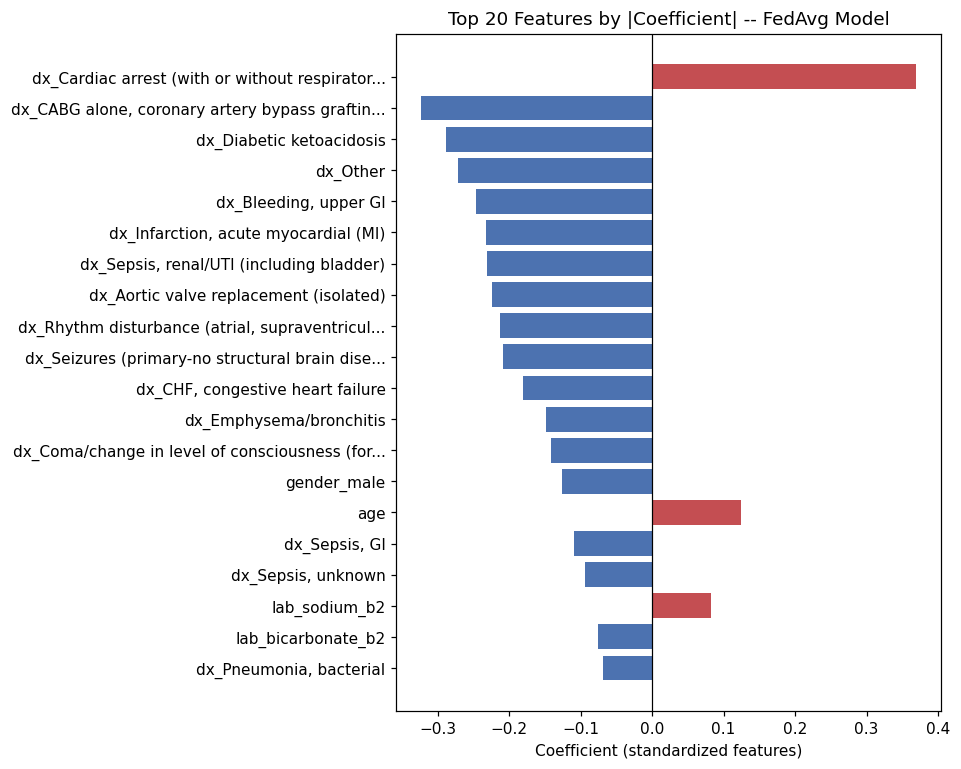

In [60]:

xai_model = train_federated(winning_ctor, winning_criterion_ctor, client_loaders, X_val, y_val,
                             seed=SEEDS[0], mu=0.0, weight_decay=1e-3, num_rounds=NUM_ROUNDS)

if winning_model_name == "LR":
    weights = xai_model.linear.weight.detach().cpu().numpy().flatten()
    bias = xai_model.linear.bias.item()

    train_counts = {}
    for col in feature_cols:
        if col.startswith(("dx_", "unittype_", "gender_")):
            train_counts[col] = int(train_df[col].sum()) if col in train_df.columns else np.nan
        else:
            train_counts[col] = np.nan

    importance_df = pd.DataFrame({
        "feature": feature_cols, "coefficient": weights, "abs_coefficient": np.abs(weights),
        "train_n_positive": [train_counts[c] for c in feature_cols],
    }).sort_values("abs_coefficient", ascending=False)
    importance_df["direction"] = np.where(importance_df["coefficient"] > 0, "increases risk", "decreases risk")
    importance_df.to_csv(RESULTS_DIR / "feature_importance_full.csv", index=False)

    top20 = importance_df.head(20)
    top20.to_csv(RESULTS_DIR / "feature_importance_top20.csv", index=False)
    print(top20[["feature", "coefficient", "direction", "train_n_positive"]].to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 8))
    colors = ["#C44E52" if c > 0 else "#4C72B0" for c in top20["coefficient"][::-1]]
    # truncate long labels for display only -- full feature names remain in the saved CSV
    display_labels = [f[:45] + "..." if len(f) > 45 else f for f in top20["feature"][::-1]]
    ax.barh(display_labels, top20["coefficient"][::-1], color=colors)
    ax.set_xlabel("Coefficient (standardized features)")
    ax.set_title("Top 20 Features by |Coefficient| -- FedAvg Model")
    ax.axvline(0, color="black", linewidth=0.8)
    plt.subplots_adjust(left=0.45)
    plt.savefig(FIGURE_DIR / "xai_feature_importance.png", bbox_inches="tight")
    plt.show()
else:
    print(f"Coefficient-based XAI implemented for LR only. Winning model is {winning_model_name} -- "
          "use permutation importance or SHAP instead if a non-linear model was selected.")


## 13. Final Consolidated Summary

All key results in one place, for direct use in the paper's tables and figures.

In [61]:

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print("\n--- Phase A: Architecture Sweep ---")
print(phaseA_summary_df[["model", "n_params", "auprc_mean", "auprc_std", "auroc_mean", "f1_mean"]].to_string(index=False))

print("\n--- Phase B: Class Imbalance Handling ---")
print(phaseB_summary_df[["config", "auprc_mean", "auroc_mean", "f1_mean"]].to_string(index=False))

print("\n--- Phase C: Centralized vs. Federated (natural conditions) ---")
print(phaseC_summary_df[["setting", "auprc_mean", "auroc_mean", "f1_mean"]].to_string(index=False))

print("\n--- Communication Overhead ---")
print(comm_df.to_string(index=False))

print("\n--- Inference Latency ---")
print(latency_df.to_string(index=False))

print("\n--- Phase D: Robustness (all perturbation types, incl. 3 Byzantine attack variants) ---")
print(phaseD_summary_df[["perturbation", "severity", "aggregator", "auprc_mean", "f1_mean"]].to_string(index=False))

print("\n--- APACHE Comparison ---")
print(apache_comparison_df.to_string(index=False))

print("\nAll results saved to:", RESULTS_DIR.resolve())
print("All figures saved to:", FIGURE_DIR.resolve())


FINAL SUMMARY

--- Phase A: Architecture Sweep ---
    model  n_params  auprc_mean  auprc_std  auroc_mean  f1_mean
       LR       392    0.383372   0.001288    0.810571 0.252532
      MLP     27201    0.400577   0.002488    0.824111 0.308685
CNN_light       593    0.191638   0.004776    0.684011 0.016973
CNN_heavy      8513    0.195134   0.000211    0.686150 0.026808

--- Phase B: Class Imbalance Handling ---
        config  auprc_mean  auroc_mean  f1_mean
    unweighted    0.383372    0.810571 0.252532
class_weighted    0.372296    0.812629 0.351830
         focal    0.373989    0.807986 0.391730

--- Phase C: Centralized vs. Federated (natural conditions) ---
    setting  auprc_mean  auroc_mean  f1_mean
centralized    0.373989    0.807986 0.391730
     fedavg    0.359233    0.803432 0.368788
    fedprox    0.358140    0.802499 0.367722

--- Communication Overhead ---
setting  model_size_MB  per_round_MB  total_MB_full_budget  n_clients  n_rounds
 fedavg       0.001568      0.294784 